PROJET SCORING 

Sasha LE POTIER

# Churn des clients dans une banque

## Import des packages et données

In [1]:
#Import des librairies
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import auc, roc_auc_score, roc_curve, confusion_matrix, recall_score, precision_score, f1_score, accuracy_score
import statsmodels.formula.api as smf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils_scoring import find_discretization_thresholds, assign_class, roc_curve_compare, mat_conf_roc_curve, analyze_target_rate_by_decile, RF_feature_importance, plot_metrics_vs_threshold, analyze_score_deciles, mat_conf

my_seed = 42

Descriptif des variables

• RowNumber : numéro de ligne dans le dataframe 

• IdClient : identifiant du client 

• NomFamille : nom de famille 

• ScoreCredit : note reflétant le risque de crédit associé à chaque client. Plus la note est 
élevée, plus le risque est faible. 

• ZoneGeo : zone géographique où se trouve le client 

• Genre : Homme / Femme 

• Age : âge du client 

• Anciennete : ancienneté du client en nombre d’année 

• Solde : solde bancaire du client 

• NbProduits : nombre de produits bancaires détenus / utilisés par le client (comptes, 
épargne, assurances…) 

• CarteCredit : utilisation d’une carte de crédit 

• MembreActif : client actif ou non (selon la présence de flux créditeurs / débiteurs sur le 
ou les comptes) 

• SalaireEstim : salaire annuel du client (estimé par la banque) 

• Churn : Oui si le client a clôturé tous ses comptes, Non sinon 

In [2]:
# Import du jeu de données
df = pd.read_csv('Churn_Banque.csv')

# Suppression des variables inutiles pour l'analyse
df_analyse = df.drop(columns =  ['RowNumber','IdClient','NomFamille'])
print("Présentation du jeu de données")
display(df_analyse)

# Séparation de la variable à expliquer et des variables explicatives en 2 jeux de données
y = df_analyse['Churn'].copy()
X = df_analyse.drop(columns =  ['Churn'])


Présentation du jeu de données


,ScoreCredit,ZoneGeo,Genre,Age,Anciennete,Solde,NbProduits,CarteCredit,MembreActif,SalaireEstim,Churn
0,596,Allemagne,Homme,32.0,3,48354.535,2,Non,Non,20894.185,Non
1,623,France,Homme,NaN,1,0.000,2,Oui,Oui,73189.650,Non
2,601,Espagne,Femme,44.0,4,0.000,2,Oui,Non,29280.655,Non
3,506,Allemagne,Homme,59.0,8,59576.050,2,Oui,Oui,85339.870,Non
4,560,Espagne,Femme,27.0,7,62497.990,1,Oui,Oui,57334.895,Non
...,...,...,...,...,...,...,...,...,...,...,...
12295,640,France,Homme,NaN,2,34216.225,2,Oui,Oui,56251.620,Oui
12296,477,France,Femme,30.0,6,65643.230,1,Oui,Non,97072.225,Non
12297,674,Espagne,Homme,32.0,2,0.000,2,Oui,Non,70289.585,Non
12298,655,France,Homme,27.0,2,65845.665,1,Oui,Non,24740.330,Non


## Traitement et nettoyage des données 

In [3]:
# Visualisation des données manquantes
nb_miss_by_var = np.sum(pd.isnull(X))
print('Nombre de données manquantes par variable \n')
print(nb_miss_by_var)

Nombre de données manquantes par variable 

ScoreCredit       0
ZoneGeo         371
Genre             0
Age             518
Anciennete        0
Solde             0
NbProduits        0
CarteCredit       0
MembreActif       0
SalaireEstim    618
dtype: int64


In [4]:
# Identification d'éventuelles valeurs aberrantes / extrêmes 
pd.options.display.float_format = '{:.2f}'.format
X.describe()

,ScoreCredit,Age,Anciennete,Solde,NbProduits,SalaireEstim
count,12300.00,11782.00,12300.00,12300.00,12300.00,11682.00
mean,650.54,38.89,5.01,38367.28,1.53,51419.71
std,96.63,10.50,2.89,31134.40,0.58,106554.08
min,350.00,14.00,0.00,0.00,1.00,5.79
25%,584.00,32.00,2.75,0.00,1.00,25508.01
50%,652.00,37.00,5.00,48662.46,1.00,50273.94
75%,717.00,44.00,7.00,63773.69,2.00,74629.04
max,850.00,105.00,10.00,125449.04,4.00,7892354.00


In [5]:
# Répartition des individus par modalité pour les variables catégorielles et discrètes 
print("Statistique descriptive des variables explicatives catégorielles \n")
for v in ['ZoneGeo', 'Genre', 'Anciennete', 'NbProduits', 'CarteCredit','MembreActif']:
    print(X[v].value_counts().sort_index())
    print('='*25)

Statistique descriptive des variables explicatives catégorielles 

Allemagne    3009
Espagne      2940
France       5980
Name: ZoneGeo, dtype: int64
Femme    5605
Homme    6695
Name: Genre, dtype: int64
0      506
1     1276
2     1293
3     1245
4     1224
5     1242
6     1194
7     1257
8     1257
9     1199
10     607
Name: Anciennete, dtype: int64
1    6261
2    5647
3     316
4      76
Name: NbProduits, dtype: int64
Non    3596
Oui    8704
Name: CarteCredit, dtype: int64
Non    5981
Oui    6319
Name: MembreActif, dtype: int64


In [6]:
# Gestion des données manquantes

# ZoneGeo
X['ZoneGeo'] = X['ZoneGeo'].fillna('NR')
print("Traitement de la variable ZoneGeo \n")
print(X['ZoneGeo'].value_counts())

# Age
X['Age']= X['Age'].fillna(X['Age'].mean().round())
print("\n Traitement de la variable Age \n")
print(X['Age'].describe())

# SalaireEstim
X['SalaireEstim']= X['SalaireEstim'].fillna(X['SalaireEstim'].median())
print("\n Traitement de la variable SalaireEstim \n")
pd.options.display.float_format = '{:.2f}'.format
print(X['SalaireEstim'].describe())

# Vérification des données manquantes
nb_miss_by_var = np.sum(pd.isnull(X))
print('Nombre de données manquantes par variable après traitement \n')
print(nb_miss_by_var)

Traitement de la variable ZoneGeo 

France       5980
Allemagne    3009
Espagne      2940
NR            371
Name: ZoneGeo, dtype: int64

 Traitement de la variable Age 

count   12300.00
mean       38.90
std        10.28
min        14.00
25%        32.00
50%        38.00
75%        43.00
max       105.00
Name: Age, dtype: float64

 Traitement de la variable SalaireEstim 

count     12300.00
mean      51362.14
std      103842.82
min           5.79
25%       26965.53
50%       50273.94
75%       73253.03
max     7892354.00
Name: SalaireEstim, dtype: float64
Nombre de données manquantes par variable après traitement 

ScoreCredit     0
ZoneGeo         0
Genre           0
Age             0
Anciennete      0
Solde           0
NbProduits      0
CarteCredit     0
MembreActif     0
SalaireEstim    0
dtype: int64


In [7]:
# Changement du type de la variable Age (float -> int)
X['Age'] = X['Age'].astype(int)

In [8]:
# Distribution de la variable à expliquer
print("Distribution de la variable à expliquer - Churn \n")
print(y.value_counts())
print(y.value_counts(normalize = True))

Distribution de la variable à expliquer - Churn 

Non    9773
Oui    2527
Name: Churn, dtype: int64
Non   0.79
Oui   0.21
Name: Churn, dtype: float64


In [9]:
# Recodage de la variable d'intérêt binaire
y = y.map({"Non": 0, "Oui": 1})
print(y.value_counts())

0    9773
1    2527
Name: Churn, dtype: int64


## Statistiques descriptives univariées 

In [10]:
# Statistiques descriptives des variables explicatives quantitatives
print("-----------------------------------------")
print("Statistiques descriptives des variables explicatives quantitatives")
pd.options.display.float_format = '{:.2f}'.format
print(X.describe())

-----------------------------------------
Statistiques descriptives des variables explicatives quantitatives
       ScoreCredit      Age  Anciennete     Solde  NbProduits  SalaireEstim
count     12300.00 12300.00    12300.00  12300.00    12300.00      12300.00
mean        650.54    38.90        5.01  38367.28        1.53      51362.14
std          96.63    10.28        2.89  31134.40        0.58     103842.82
min         350.00    14.00        0.00      0.00        1.00          5.79
25%         584.00    32.00        2.75      0.00        1.00      26965.53
50%         652.00    38.00        5.00  48662.46        1.00      50273.94
75%         717.00    43.00        7.00  63773.69        2.00      73253.03
max         850.00   105.00       10.00 125449.04        4.00    7892354.00


In [11]:
# Variables categorielles ou discrètes 
print("Statistique descriptive des variables explicatives catégorielles \n")
for v in ['ZoneGeo', 'Genre', 'Anciennete', 'NbProduits', 'CarteCredit','MembreActif']:
    print(X[v].value_counts().sort_index())
    print('='*25)

Statistique descriptive des variables explicatives catégorielles 

Allemagne    3009
Espagne      2940
France       5980
NR            371
Name: ZoneGeo, dtype: int64
Femme    5605
Homme    6695
Name: Genre, dtype: int64
0      506
1     1276
2     1293
3     1245
4     1224
5     1242
6     1194
7     1257
8     1257
9     1199
10     607
Name: Anciennete, dtype: int64
1    6261
2    5647
3     316
4      76
Name: NbProduits, dtype: int64
Non    3596
Oui    8704
Name: CarteCredit, dtype: int64
Non    5981
Oui    6319
Name: MembreActif, dtype: int64


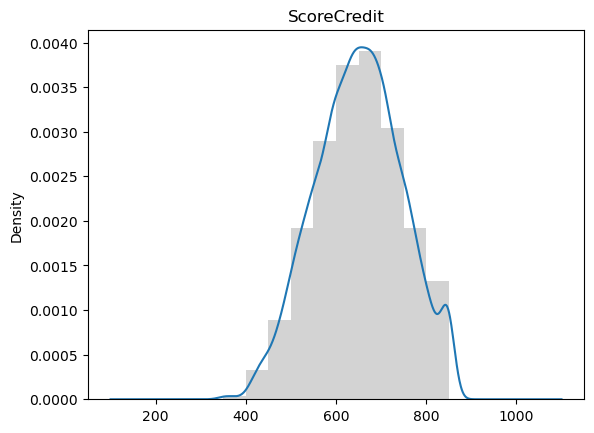

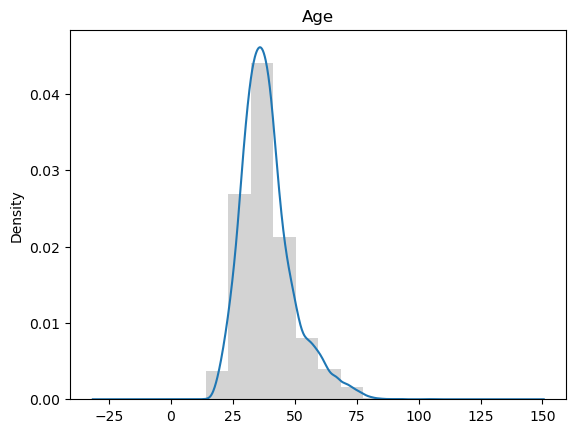

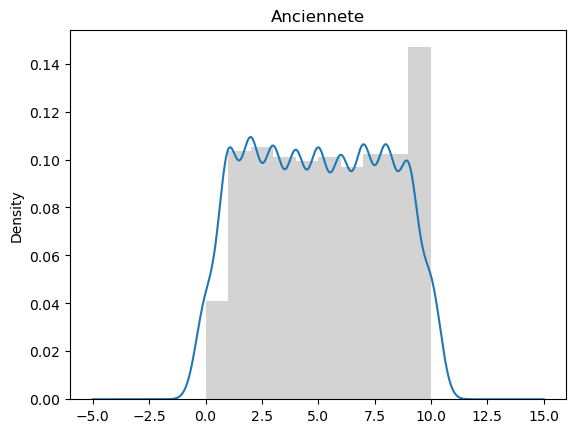

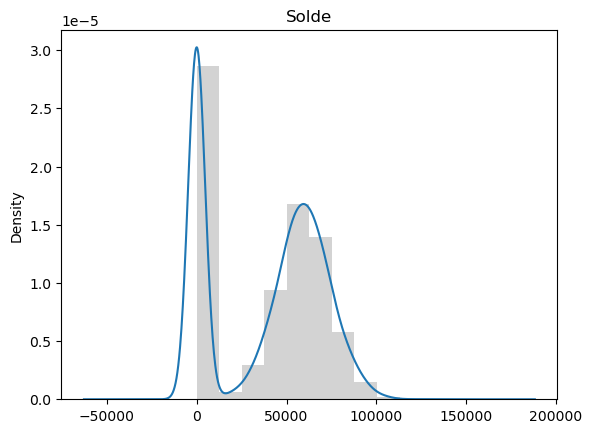

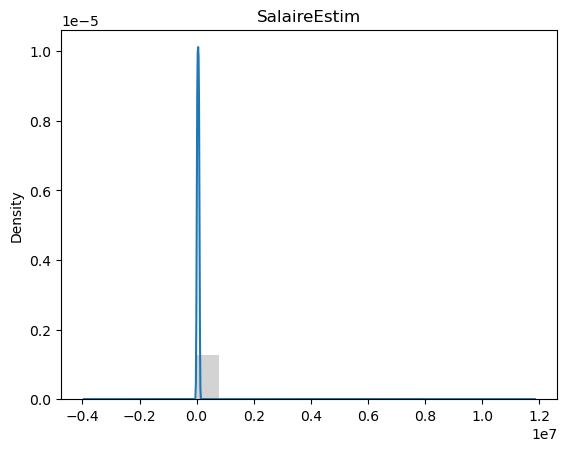

In [12]:
# Variables explicatives quantitatives

cont_vars = ['ScoreCredit','Age','Anciennete','Solde','SalaireEstim']

for i in cont_vars : 
    df[i].plot(kind = "hist", density = True, color = "lightgrey")
    df[i].plot(kind = "kde")
    plt.title(i)
    plt.show()


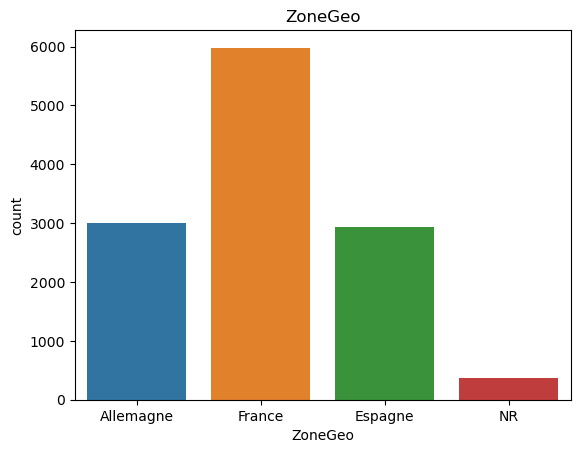

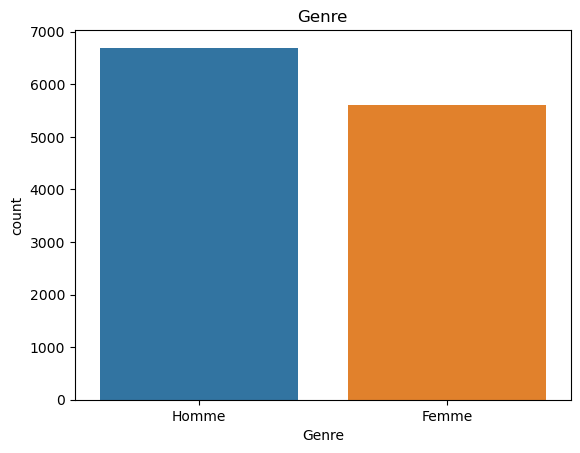

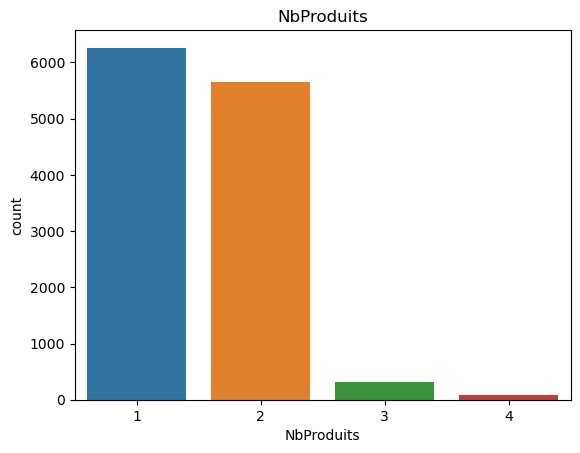

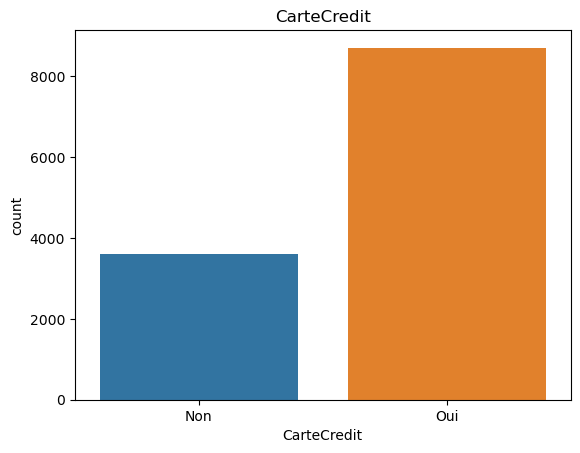

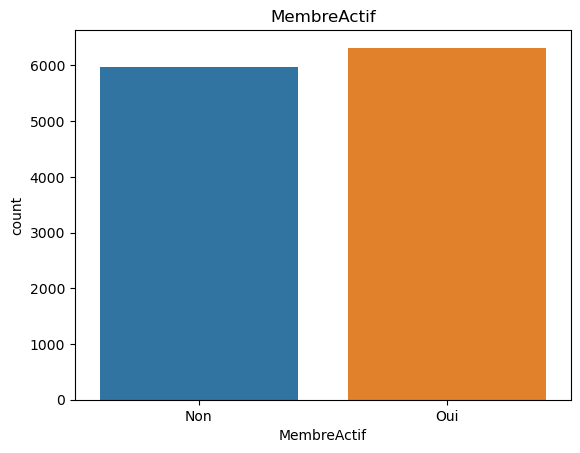

In [13]:
# Variables explciatives catégorielles

cat_vars = ['ZoneGeo', 'Genre', 'NbProduits', 'CarteCredit', 'MembreActif']
 
for i in cat_vars : 
    sns.countplot(data = X, x = i)
    plt.title(i)
    plt.show()

## Partitionnement des données TRAIN / TEST

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify = y, 
                                           random_state = my_seed)

# Vérifiez que les distributions de y sont les mêmes entre échantillons d'apprentissage et de test
print('Distrib y - Train\n', y_train.value_counts(normalize = True))
print('='*25)
print('Distrib y - Test\n', y_test.value_counts(normalize = True))

Distrib y - Train
 0   0.79
1   0.21
Name: Churn, dtype: float64
Distrib y - Test
 0   0.79
1   0.21
Name: Churn, dtype: float64


In [15]:
# Résumé des informations sur les jeux de données d'entrainement
# Variables explicatives
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8610 entries, 4722 to 8525
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ScoreCredit   8610 non-null   int64  
 1   ZoneGeo       8610 non-null   object 
 2   Genre         8610 non-null   object 
 3   Age           8610 non-null   int32  
 4   Anciennete    8610 non-null   int64  
 5   Solde         8610 non-null   float64
 6   NbProduits    8610 non-null   int64  
 7   CarteCredit   8610 non-null   object 
 8   MembreActif   8610 non-null   object 
 9   SalaireEstim  8610 non-null   float64
dtypes: float64(2), int32(1), int64(3), object(4)
memory usage: 706.3+ KB


In [16]:
# Variable d'intérêt
y_train.info()

<class 'pandas.core.series.Series'>
Int64Index: 8610 entries, 4722 to 8525
Series name: Churn
Non-Null Count  Dtype
--------------  -----
8610 non-null   int64
dtypes: int64(1)
memory usage: 134.5 KB


## Croisement de variables - Analyses bivariées

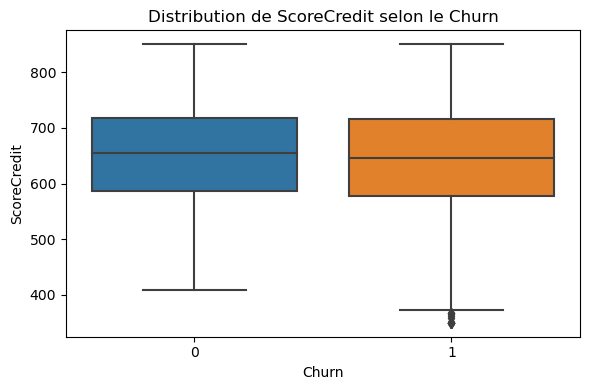

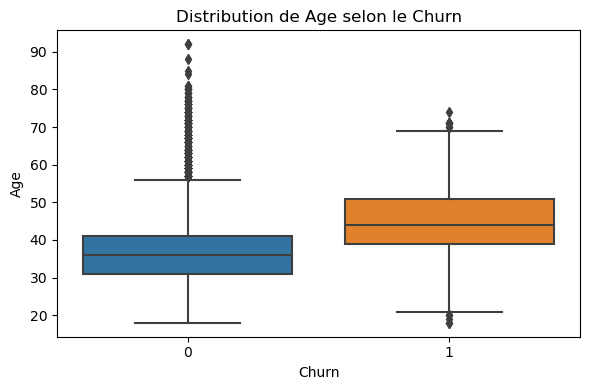

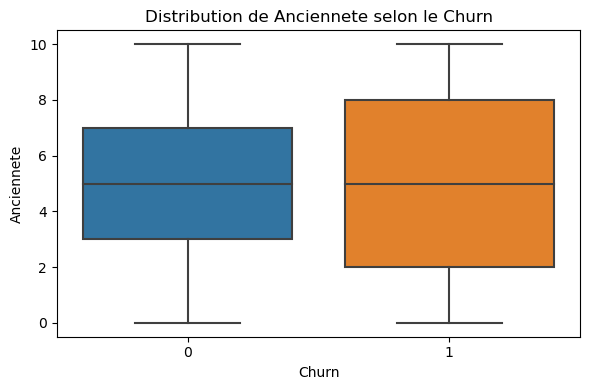

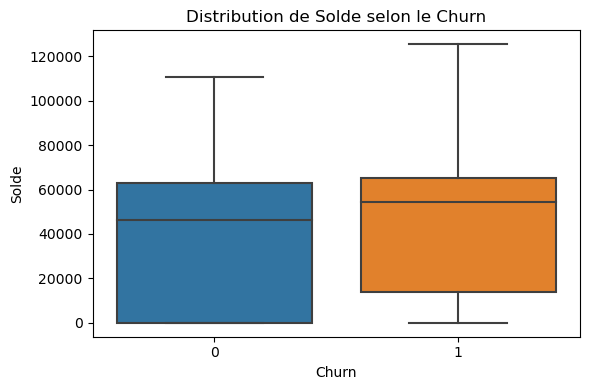

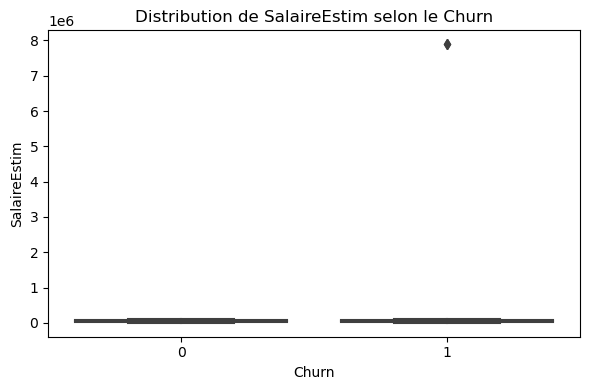

In [17]:
for var in cont_vars:
    plt.figure(figsize=(6,4))
    sns.boxplot(
        x=y_train,
        y=X_train[var],
        showfliers=True
    )
    plt.title(f"Distribution de {var} selon le Churn")
    plt.xlabel("Churn")
    plt.ylabel(var)
    plt.tight_layout()
    plt.show()

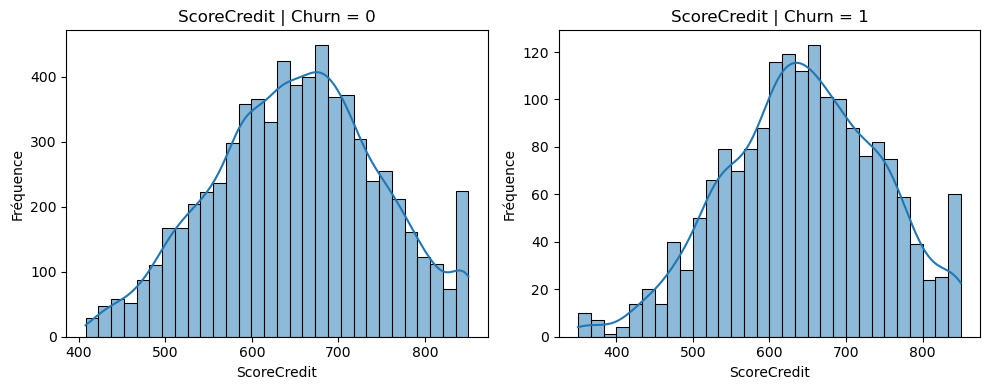

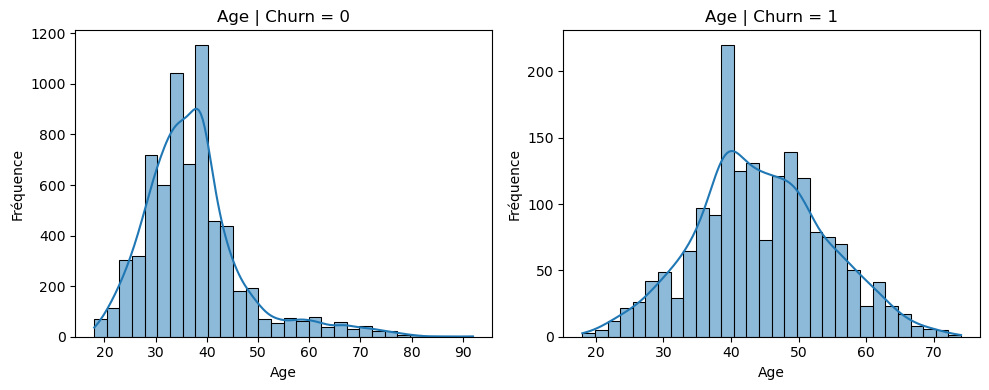

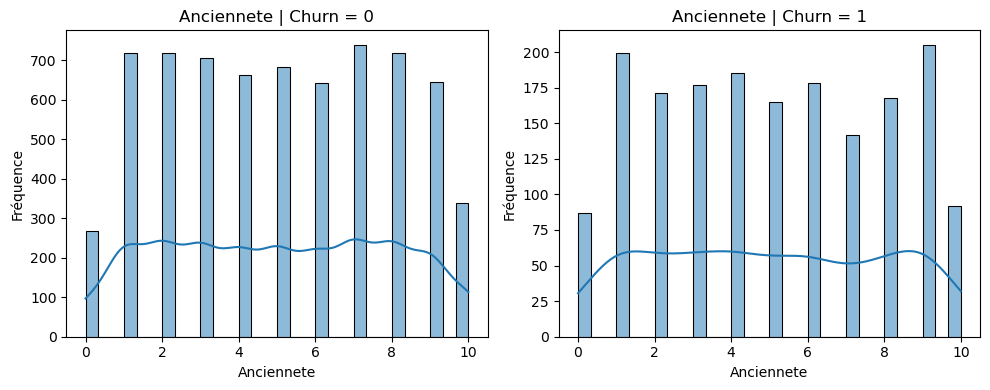

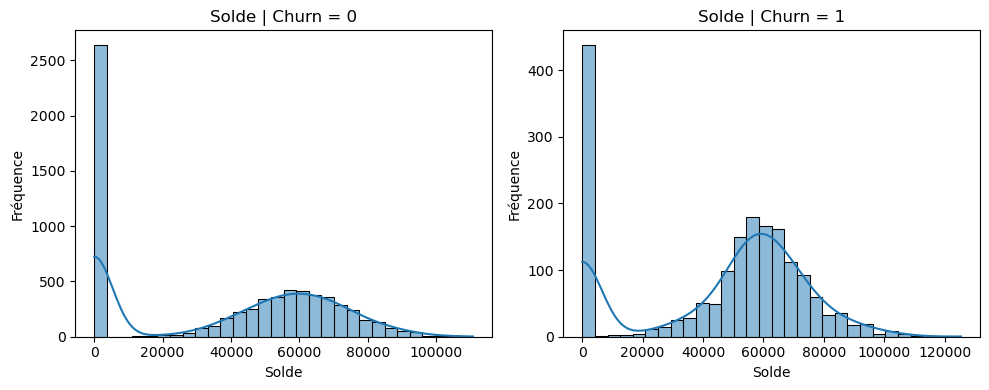

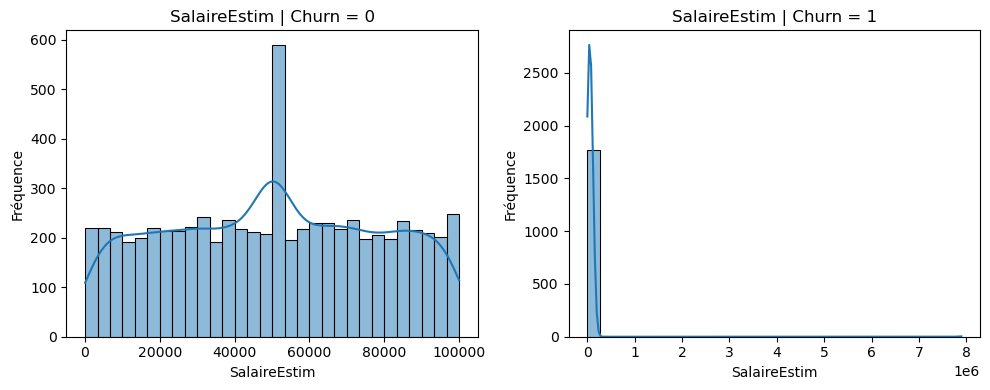

In [18]:
for var in cont_vars:
    plt.figure(figsize=(10,4))
    # Churn = 0
    plt.subplot(1, 2, 1)
    sns.histplot(
        X_train.loc[y_train == 0, var],
        bins=30,
        kde=True
    )
    plt.title(f"{var} | Churn = 0")
    plt.xlabel(var)
    plt.ylabel("Fréquence")
    
    # Churn = 1
    plt.subplot(1, 2, 2)
    sns.histplot(
        X_train.loc[y_train == 1, var],
        bins=30,
        kde=True
    )
    plt.title(f"{var} | Churn = 1")
    plt.xlabel(var)
    plt.ylabel("Fréquence")
    plt.tight_layout()
    plt.show()

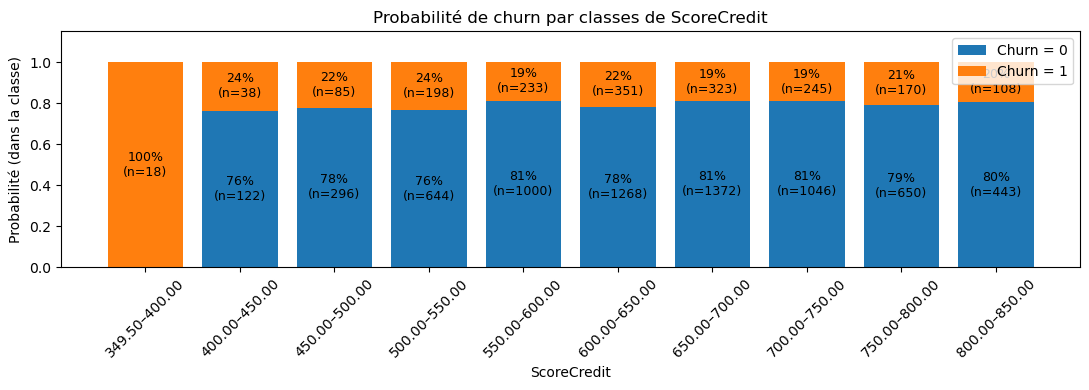

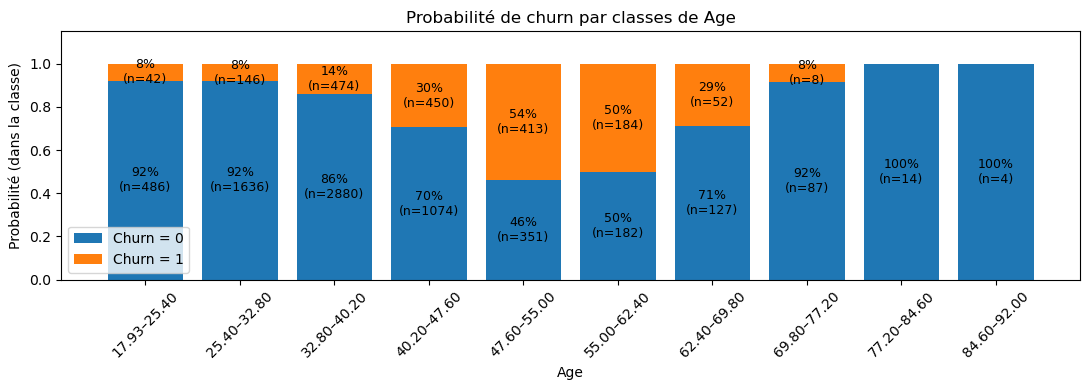

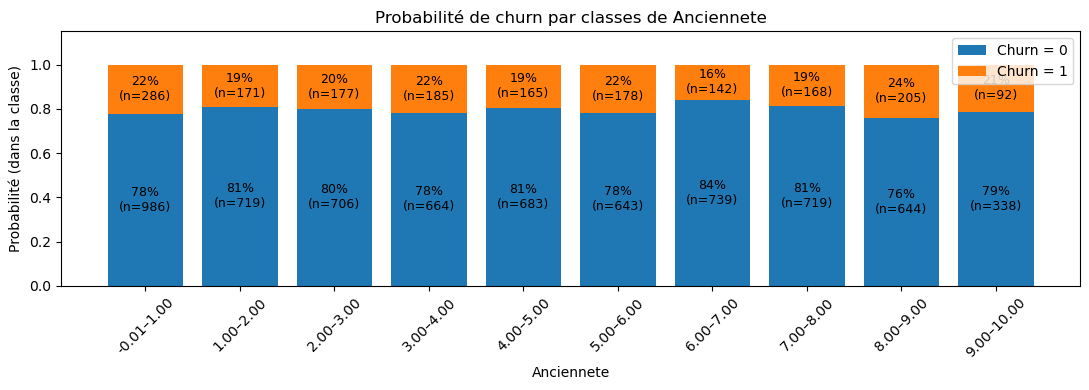

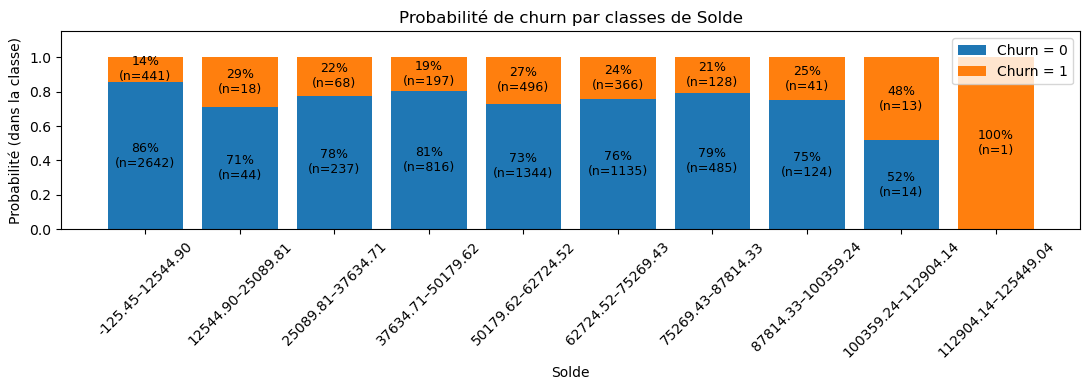

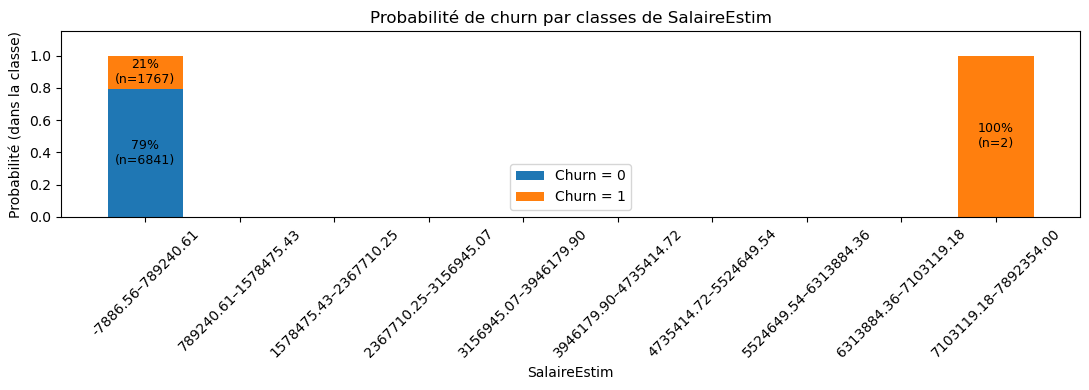

In [19]:
y_series = pd.Series(y_train, index=X_train.index, name="Churn")
 
def stacked_prob_hist_with_counts(x, y, var_name, bins=10):
    df = pd.DataFrame({var_name: x, "Churn": y}).dropna()
 
    # Intervalles
    df["bin"] = pd.cut(df[var_name], bins=bins)
 
    # Effectifs par intervalles et churn
    counts = (
        df.groupby(["bin", "Churn"])
          .size()
          .unstack(fill_value=0)
    )

    for c in [0, 1]:
        if c not in counts.columns:
            counts[c] = 0
    counts = counts[[0, 1]]
 
    # Proportions (dans chaque intervalle) => somme = 1
    probs = counts.div(counts.sum(axis=1), axis=0).fillna(0)
 
    # Labels des intervalles
    xlabels = [f"{interval.left:.2f}–{interval.right:.2f}" for interval in probs.index]
 
    # Graphique
    fig, ax = plt.subplots(figsize=(11, 4))
    bottom = np.zeros(len(probs))
 
    bars0 = ax.bar(xlabels, probs[0].values, bottom=bottom, label="Churn = 0")
    bottom += probs[0].values
    bars1 = ax.bar(xlabels, probs[1].values, bottom=bottom, label="Churn = 1")
 
    # Mise en forme
    ax.set_ylim(0, 1.15)
    
    for i in range(len(probs)):
        for churn_val in [0, 1]:
            p = probs.iloc[i][churn_val]
            n = counts.iloc[i][churn_val]
            if n == 0:
                continue  
 
            y0 = probs.iloc[i][0] if churn_val == 1 else 0
            y_center = y0 + p / 2
 
            ax.text(
                i, y_center,
                f"{p*100:.0f}%\n(n={int(n)})",
                ha="center", va="center",
                fontsize=9
            )
 
    ax.set_title(f"Probabilité de churn par classes de {var_name}")
    ax.set_xlabel(var_name)
    ax.set_ylabel("Probabilité (dans la classe)")
    ax.legend()
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()
 
# Boucle sur toutes tes variables continues
for var in cont_vars:
    stacked_prob_hist_with_counts(X_train[var], y_series, var, bins=10)

## Modélisation

### Transformation des variables catégorielles en indicatrices

In [20]:
cat_vars = ['ZoneGeo', 'Genre', 'CarteCredit', 'MembreActif']
cont_vars = ['ScoreCredit','Age','Anciennete','Solde','NbProduits','SalaireEstim']

ohe = OneHotEncoder(categories = "auto", drop = 'first', sparse_output = False, dtype = np.int8, handle_unknown = 'ignore')
ohe.fit(X_train[cat_vars])

X_train_dummies = pd.DataFrame(ohe.transform(X_train[cat_vars]), columns = ohe.get_feature_names_out(), index = X_train.index)
X_test_dummies = pd.DataFrame(ohe.transform(X_test[cat_vars]), columns = ohe.get_feature_names_out(), index = X_test.index)

In [21]:
# Initialisation d'un dictionnaire pour stocker les courbes ROC des échantillons de test des meilleurs modèles
dic_roc = {}

### Arbres de décision

In [22]:
# Initialisation d'un dictionnaire pour stocker les courbes ROC des échantillons de test des arbres de décision
dic_roc_decisiontree = {}

In [23]:
# Création des dataframes X_train et X_test spécifiques à l'arbre de décision
tree_X_train = pd.concat([X_train.drop(columns = cat_vars), X_train_dummies], axis = 1)
tree_X_test = pd.concat([X_test.drop(columns = cat_vars), X_test_dummies], axis = 1)

#### Paramètres définis manuellement


Arbre de décision n° 1


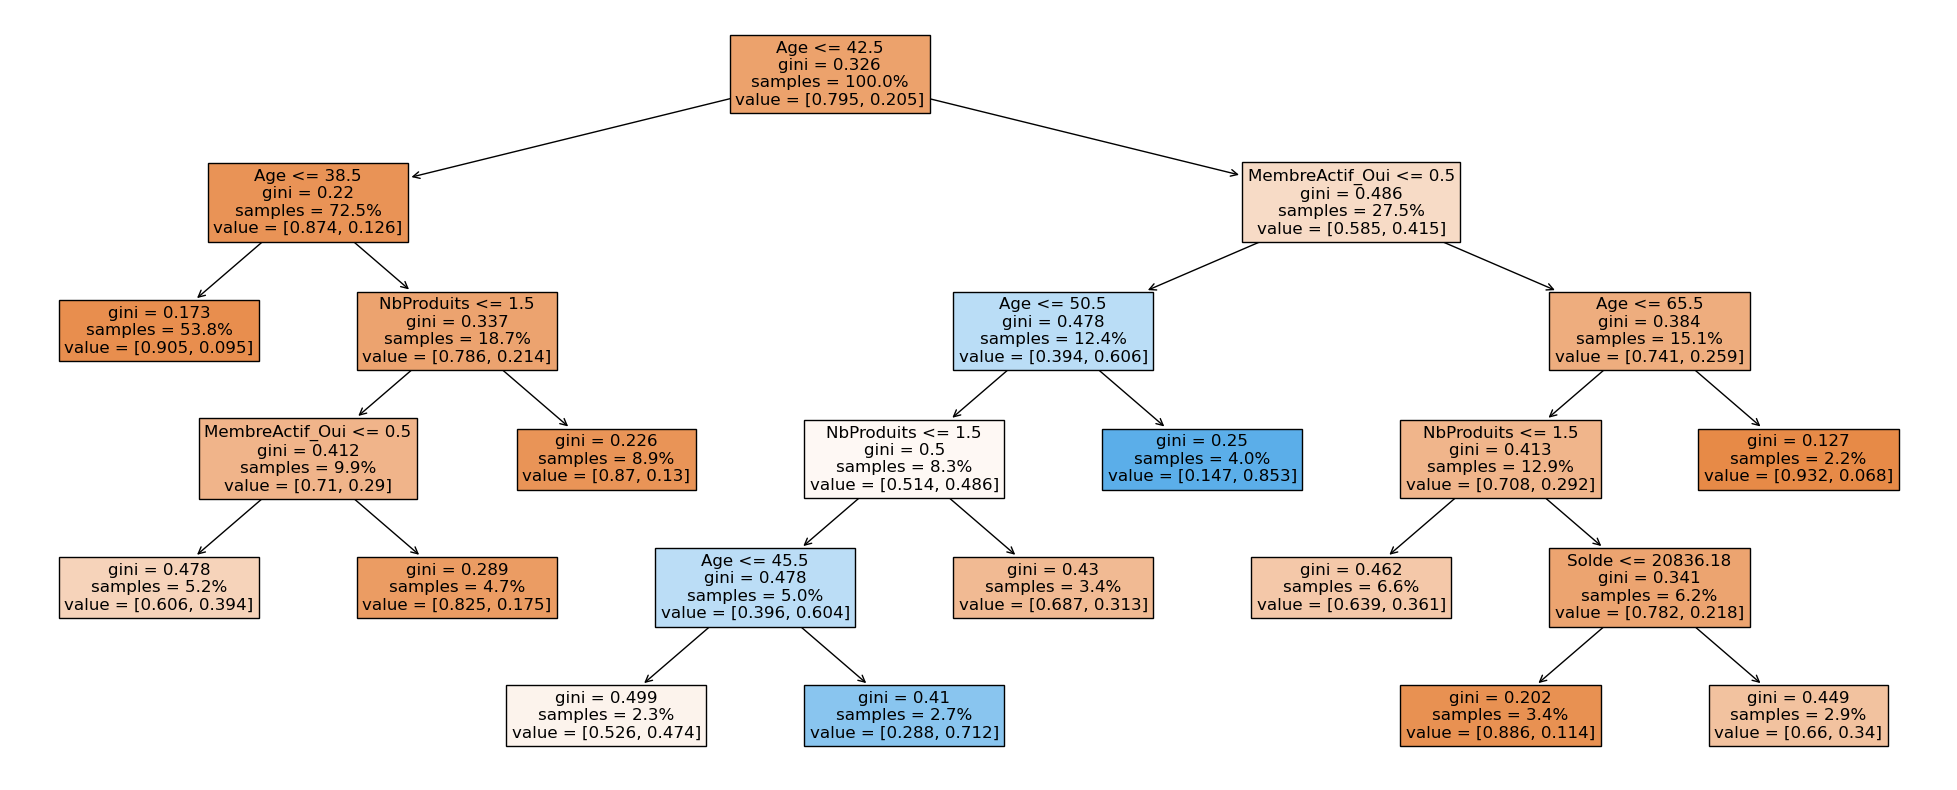

In [24]:
# Spécification de l'arbre de décision
print('\n'+'='*50)
mod = 'Arbre de décision n° 1'
print(mod)
print('='*50)
tree1 = DecisionTreeClassifier(criterion = 'gini', min_samples_leaf = 0.02, max_leaf_nodes = 12, 
                               max_depth = 6, random_state = my_seed)

# Lancer l'apprentissage du modèle
tree1.fit(tree_X_train, y_train)

# Editer le graphique correspondant à l'arbre
X_col = list(tree_X_train.columns)
fig = plt.figure(figsize=(25,10))
arbredec = plot_tree(tree1, feature_names=X_col, proportion = True, filled=True, fontsize = 12)
plt.show()

La coupure candidate qui optimise le critère de découpe est la variable "Age". Le seuil pour la première coupure est de 42,5.

On va s'intéresser aux noeuds situées à droite de l'arbre car c'est ici que se trouve les indivudus ayant la plus grande probabilité de quitter la banque.

Les personnes ayant plus de 42,5 ans et étant classés comme étant non actif (selon la présence de flux créditeurs / débiteurs sur le ou les comptes) représentent 12,4 % de notre jeu de données et 60,6 % d'entre eux quittent la banque.

Les personnes ayant plus de 50,5 ans et étant classés comme étant non actif représentent 4 % de notre jeu de données et 85,3 % d'entre eux quittent la banque.

Les personnes ayant un âge supérieur à 42,5 et inférieur ou égal à 50,5 ans, étant classés comme étant non actif, et ayant 1 produit représentent 5 % de notre jeu de données et 60,4 % d'entre eux quittent la banque.

Les personnes ayant un âge supérieur à 45,5 et inférieur ou égal à 50,5 ans, étant classés comme étant non actif, et ayant 1 produit représentent 2,7 % de notre jeu de données et 71,2 % d'entre eux quittent la banque.

Echantillon train
[[5625 1216]
 [ 658 1111]]
              precision    recall  f1-score   support

           0       0.90      0.82      0.86      6841
           1       0.48      0.63      0.54      1769

    accuracy                           0.78      8610
   macro avg       0.69      0.73      0.70      8610
weighted avg       0.81      0.78      0.79      8610

Modèle Arbre de décision n° 1 - Echantillon train - Aire sous la courbe ROC (AUC) : 76.2%
Echantillon test
[[2389  543]
 [ 287  471]]
              precision    recall  f1-score   support

           0       0.89      0.81      0.85      2932
           1       0.46      0.62      0.53       758

    accuracy                           0.78      3690
   macro avg       0.68      0.72      0.69      3690
weighted avg       0.80      0.78      0.79      3690

Modèle Arbre de décision n° 1 - Echantillon test - Aire sous la courbe ROC (AUC) : 75.4%


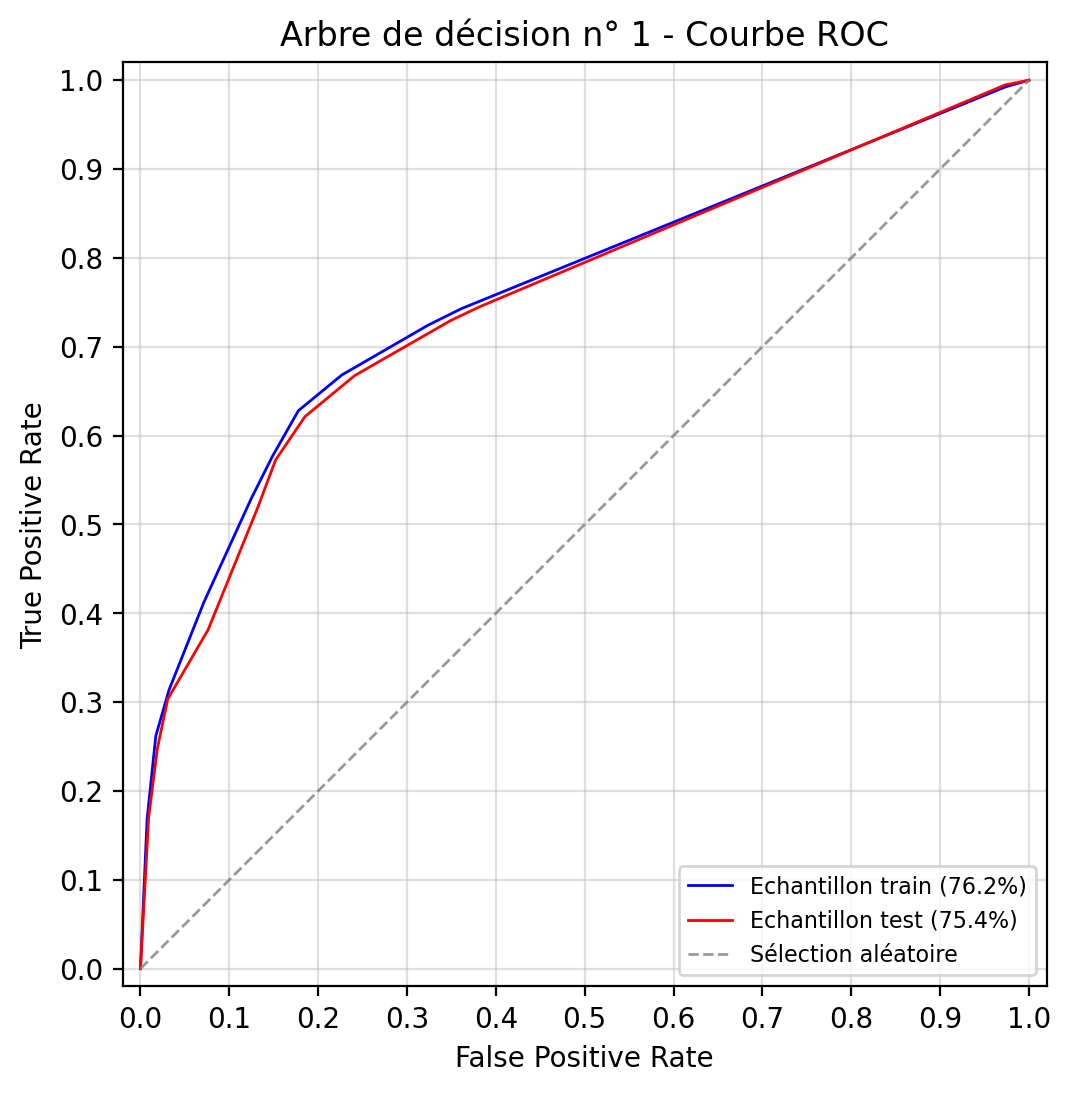

Attention : certains bins sont dupliqués. Ajustement à 6 bins.
[0, 0.06806282722513089, 0.095361380798274, 0.12992125984251968, 0.17530864197530865, 0.36140350877192984, 0.39414414414414417, 0.853448275862069]
   score_bin  target_rate_train  target_rate_test bin_label
0          5               0.72              0.72         1
1          6               0.39              0.31         2
2          7               0.34              0.36         3
3          8               0.18              0.18         4
4          9               0.13              0.12         5
5         10               0.09              0.10      6-10


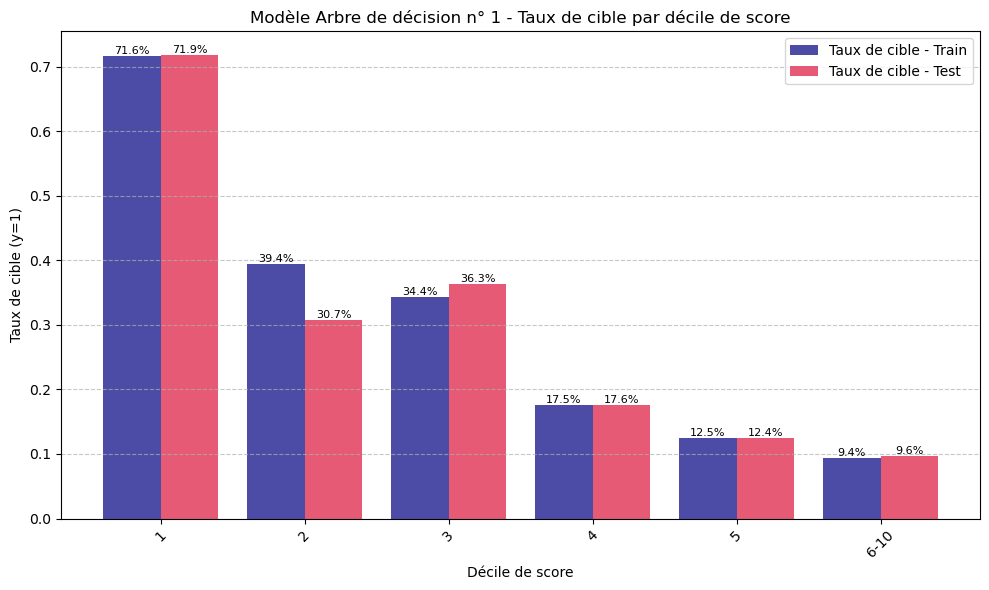

In [25]:
# Appliquer le modèle à chaque échantillon pour récupérer les probabilités (predict_proba)
proba_train = tree1.predict_proba(tree_X_train)[:, 1]
proba_test = tree1.predict_proba(tree_X_test)[:, 1]

# Spécification du seuil à utiliser pour la matrice de confusion 
cut_off = y_train.mean()  

# Récupérer les prédictions binaires selon le cut_off
y_pred_train = (proba_train > cut_off).astype('int8')
y_pred_test = (proba_test > cut_off).astype('int8')
    
# Editer les matrices de confusion des échantillons d’apprentissage et de test ainsi que les courbes ROC associées
mat_conf_roc_curve(dic_roc_decisiontree, mod, y_train, y_test, y_pred_train, y_pred_test, proba_train, proba_test)
analyze_target_rate_by_decile(mod, 10, y_train, y_test, proba_train, proba_test)

**Train :**

5 625 clients : Le modèle a bien prédit qu’ils restaient. → Pas d’action nécessaire.

1 111 clients : Le modèle a bien prédit qu’ils partaient. → Mise en place d'actions ciblées (ex : offres de fidélisation).

658 clients : Le modèle a cru qu’ils restaient, mais ils sont partis. → Perte de chiffre d’affaires, opportunité manquée.

1216 clients : Le modèle a cru qu’ils partaient, mais ils sont restés. → Ressources gaspillées (ex : appels, promotions inutiles).

Notre accuracy est assez bon, il est de 78 %, à voir si il est fiable en interprétant d'autres indicateurs.

Recall : 63 % des clients quittant la banque, ont été correctement identifiés.

Precision : Parmis les clients qui ont été prédit comme quittant la banque, 48 % d'entre eux quittent réellement la banque.

**Test :**

2 389 clients : Le modèle a bien prédit qu’ils restaient. → Pas d’action nécessaire.

471 clients : Le modèle a bien prédit qu’ils partaient. → Mise en place d'actions ciblées (ex : offres de fidélisation).

287 clients : Le modèle a cru qu’ils restaient, mais ils sont partis. → Perte de chiffre d’affaires, opportunité manquée.

543 clients : Le modèle a cru qu’ils partaient, mais ils sont restés. → Ressources gaspillées (ex : appels, promotions inutiles).

Notre accuracy est assez bon, il est de 78 %, à voir si il est fiable en interprétant d'autres indicateurs.

Recall : 62 % des clients quittant la banque, ont été correctement identifiés.

Précision : Parmis les clients qui ont été prédit comme quittant la banque, 46 % d'entre eux quittent réellement la banque.

L'aire sous la courbe (AUC) pour l'échantillon train est de 76,2 % et pour l'échantillon test il est de 75,4 %.

L'AUC est donc plus grand pour l'échantillon train, ce qui est normal et la l'écart entre les AUC n'est pas très grande ce qui montre que le modèle ne réalise pas de sur apprentissage sur l'échantillon train.

**Taux de cible par décile de score :**

Un score à été attribué à chaque client, sa probabilité de quitter la banque. Ces scores ont été triés par ordre décroissant, puis découpés en décile afin de visualiser la proportion de client quittant la banque par décile et pour l'échantillon train et test.

On observe une décroissance linéaire des chances de quitter la banque, ce qui prouve que le modèle arrive à bien attribuer des scores aux clients selon sa probabilité de partir.

Sur la 1ère tranche de 10 %, les clients quittent la banque à 71,6 % des cas et on constate une forte chute des clients qui quittent la banque à 39,4 % sur la 2ème tranche de 10 %.


Sur la 3ème tranche de 10 %, les clients quittent la banque à 34,4 % des cas.

#### Ajustement des paramètres

##### Optimiser la précision

In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Exploration des paramètres 
grid_param={
    'max_depth' :[1,2,3,4,5,6,7,8,9,10],
    'criterion': ['gini', 'entropy'],
    'min_samples_leaf': [1,2,3,4,5,6,7,8,9,10],
    'max_leaf_nodes' : [5,6,7,8,9,10,11,12,13,14,15]
}

gd_sr=GridSearchCV(estimator=DecisionTreeClassifier(), param_grid=grid_param, scoring='precision', n_jobs=-1, 
                   cv=5, return_train_score = True)

# Entrainement du modèle
gd_sr.fit(tree_X_train, y_train)

# Attributs de l'objet
print(gd_sr.best_score_)
print(gd_sr.best_params_)
print(gd_sr.best_estimator_)

0.8367231954608728
{'criterion': 'entropy', 'max_depth': 3, 'max_leaf_nodes': 8, 'min_samples_leaf': 1}
DecisionTreeClassifier(criterion='entropy', max_depth=3, max_leaf_nodes=8)



Arbre de décision n°2 - Paramètres optimisant la précision


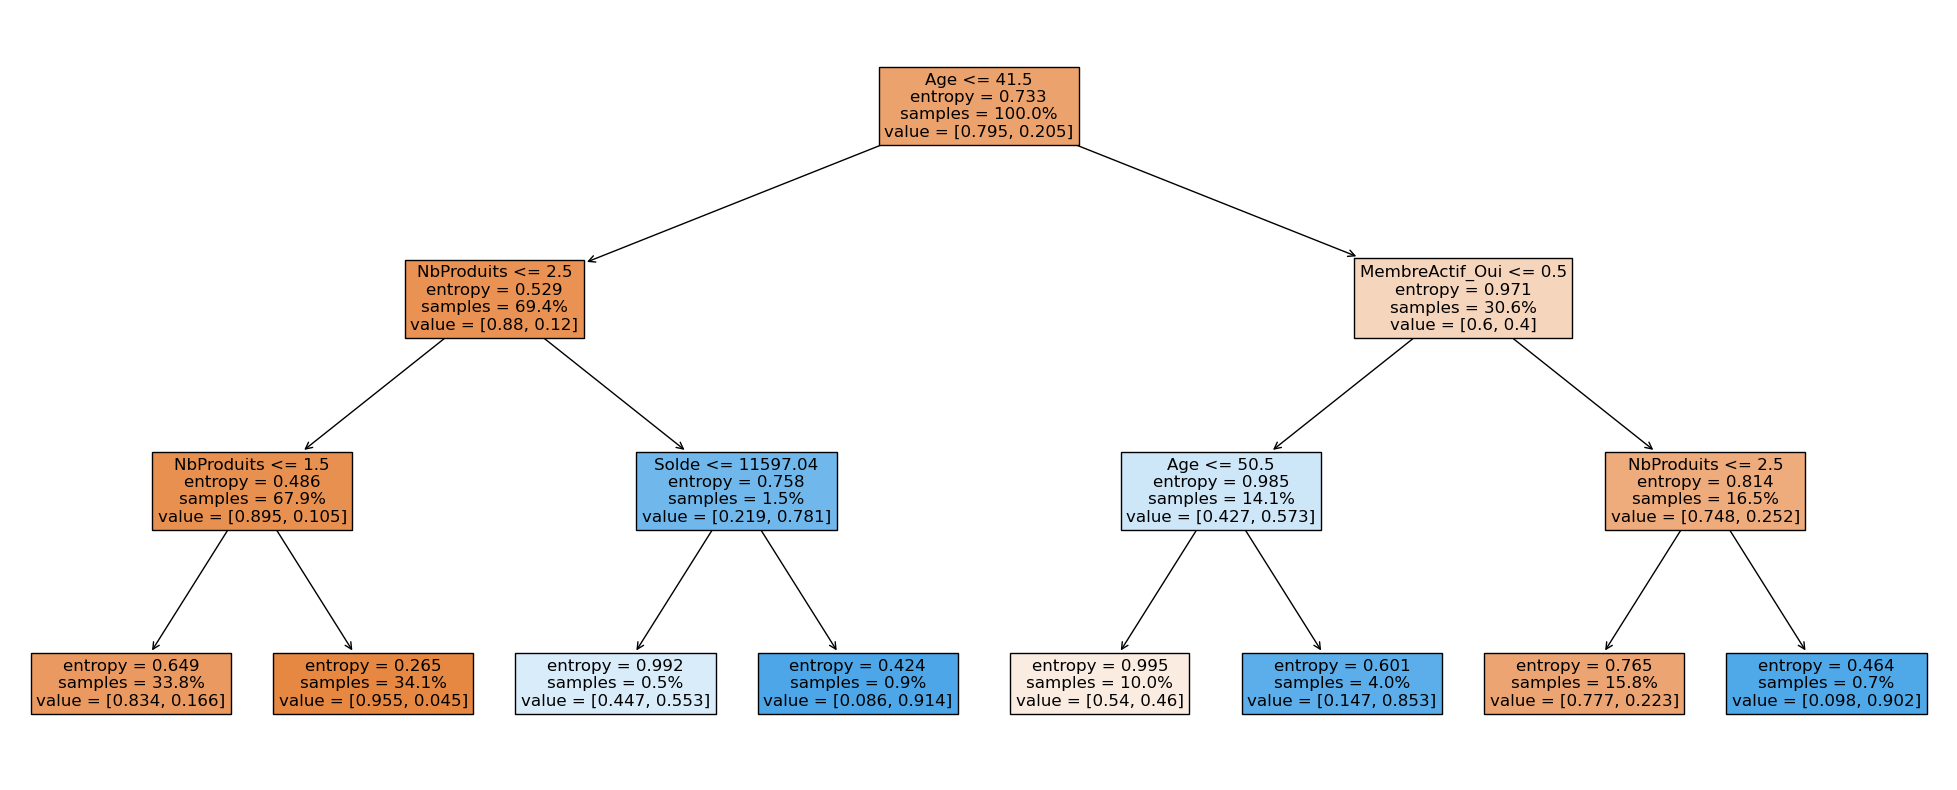

In [27]:
# Spécification de l'arbre de décision - optimisant la précision
print('\n'+'='*50)
mod = 'Arbre de décision n°2 - Paramètres optimisant la précision'
print(mod)
print('='*50)
tree2 = DecisionTreeClassifier(criterion = 'entropy', min_samples_leaf = 1, max_leaf_nodes = 8, 
                               max_depth = 3, random_state = my_seed)

# Lancer l'apprentissage du modèle
tree2.fit(tree_X_train, y_train)

# Editer le graphique correspondant à l'arbre
X_col = list(tree_X_train.columns)
fig = plt.figure(figsize=(25,10))
arbredec = plot_tree(tree2, feature_names=X_col, proportion = True, filled=True, fontsize = 12)
plt.show()

Echantillon train
[[5231 1610]
 [ 616 1153]]
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      6841
           1       0.42      0.65      0.51      1769

    accuracy                           0.74      8610
   macro avg       0.66      0.71      0.67      8610
weighted avg       0.80      0.74      0.76      8610

Modèle Arbre de décision n°2 - Paramètres optimisant la précision - Echantillon train - Aire sous la courbe ROC (AUC) : 78.9%
Echantillon test
[[2235  697]
 [ 268  490]]
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      2932
           1       0.41      0.65      0.50       758

    accuracy                           0.74      3690
   macro avg       0.65      0.70      0.66      3690
weighted avg       0.79      0.74      0.76      3690

Modèle Arbre de décision n°2 - Paramètres optimisant la précision - Echantillon test - Aire sous la courbe ROC (AUC) : 78.3%


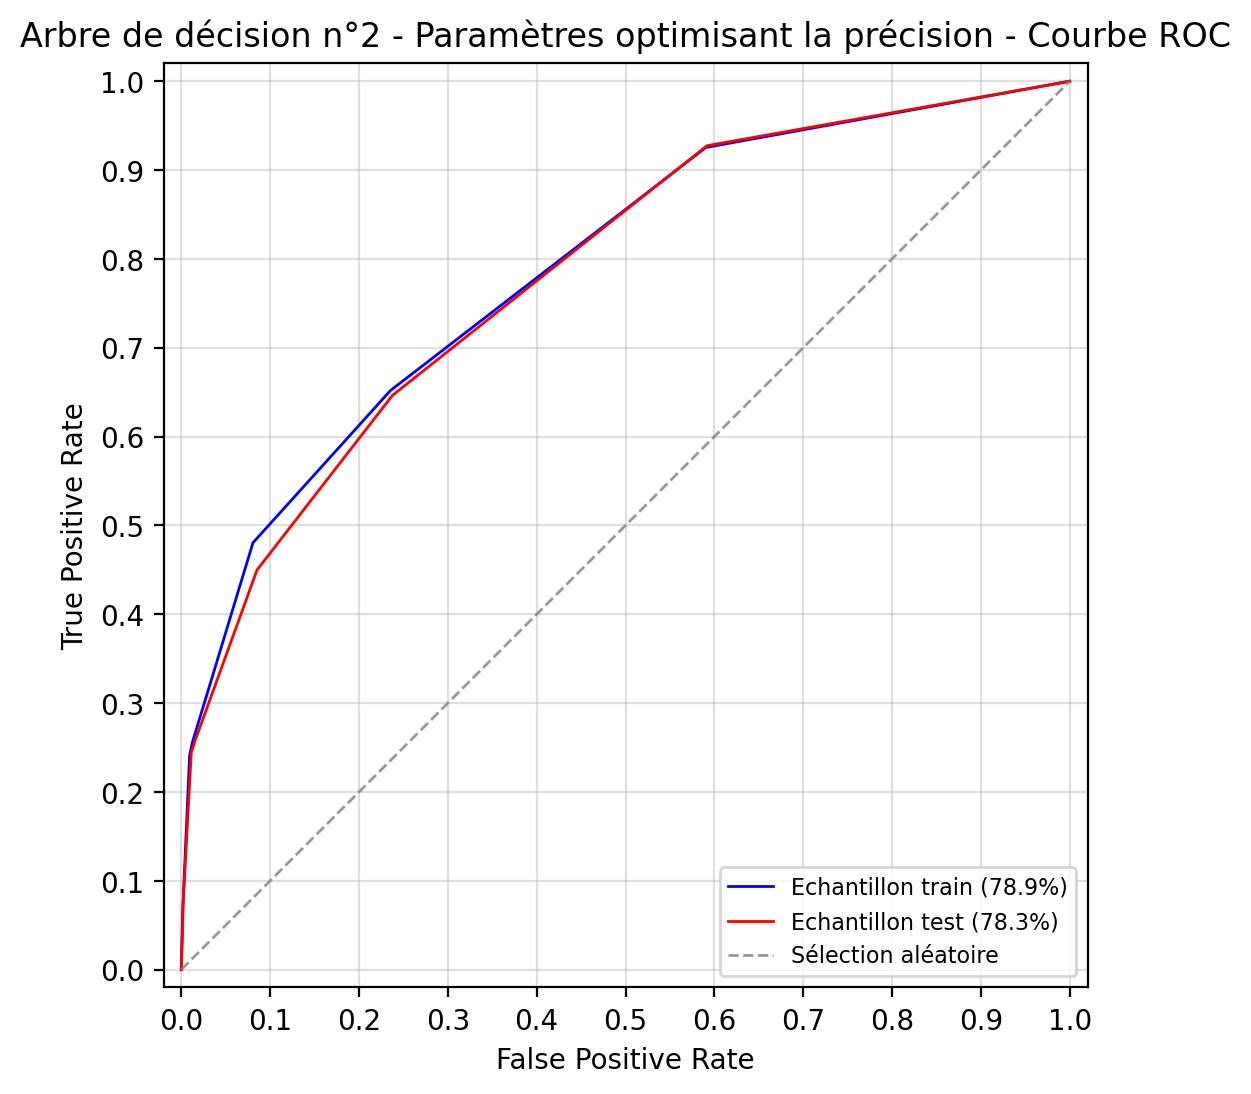

Attention : certains bins sont dupliqués. Ajustement à 4 bins.
[0, 0.044989775051124746, 0.16615173360796429, 0.22263041880969875, 0.4601156069364162, 0.9135802469135802]
   score_bin  target_rate_train  target_rate_test bin_label
0          7               0.84              0.81         1
1          8               0.46              0.42         2
2          9               0.22              0.25       3-4
3         10               0.11              0.11       5-7


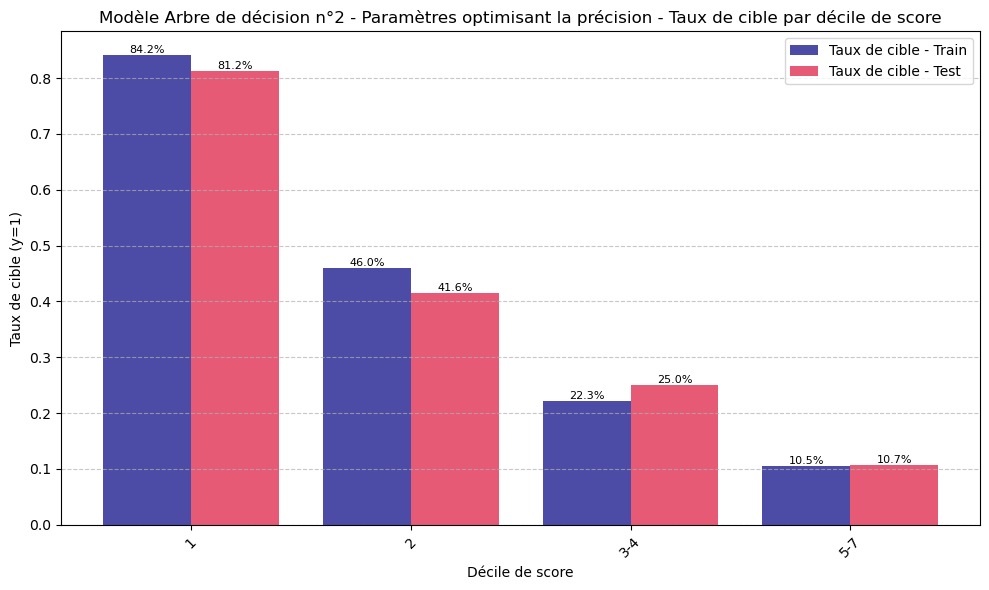

In [28]:
# Appliquer le modèle à chaque échantillon pour récupérer les probabilités (predict_proba)
proba_train = tree2.predict_proba(tree_X_train)[:, 1]
proba_test = tree2.predict_proba(tree_X_test)[:, 1]

# Spécification du seuil à utiliser pour la matrice de confusion 
cut_off = y_train.mean()  

# Récupérer les prédictions binaires selon le cut_off
y_pred_train = (proba_train > cut_off).astype('int8')
y_pred_test = (proba_test > cut_off).astype('int8')
    
# Editer les matrices de confusion des échantillons d’apprentissage et de test ainsi que les courbes ROC associées
mat_conf_roc_curve(dic_roc_decisiontree, mod, y_train, y_test, y_pred_train, y_pred_test, proba_train, proba_test)
analyze_target_rate_by_decile(mod, 10, y_train, y_test, proba_train, proba_test)

**Train :**

Notre accuracy est assez bon, il est de 74 %, à voir si il est fiable en interprétant d'autres indicateurs.

Recall : 65 % des clients quittant la banque, ont été correctement identifiés.

Precision : Parmis les clients qui ont été prédit comme quittant la banque, 42 % d'entre eux quittent réellement la banque.

**Test :**

Notre accuracy est assez bon, il est de 74 %, à voir si il est fiable en interprétant d'autres indicateurs.

Recall : 65 % des clients quittant la banque, ont été correctement identifiés.

Précision : Parmis les clients qui ont été prédit comme quittant la banque, 41 % d'entre eux quittent réellement la banque.

L'aire sous la courbe (AUC) pour l'échantillon train est de 78,9 % et pour l'échantillon test il est de 78,3 %.

L'AUC est donc plus grand pour l'échantillon train, ce qui est normal et la l'écart entre les AUC n'est pas très grande ce qui montre que le modèle ne réalise pas de sur apprentissage sur l'échantillon train.

**Taux de cible par décile de score :**

Un score à été attribué à chaque client, sa probabilité de quitter la banque. Ces scores ont été triés par ordre décroissant, puis découpés en décile afin de visualiser la proportion de client quittant la banque par décile et pour l'échantillon train et test.

On observe une décroissance linéaire des chances de quitter la banque, ce qui prouve que le modèle arrive à bien attribuer des scores aux clients selon sa probabilité de partir.

Sur la 1ère tranche de 10 %, les clients quittent la banque à 84,2 % des cas et on constate une forte chute des clients qui quittent la banque à 46 % sur la 2ème tranche de 10 %.


Sur la 3ème tranche de 10 %, les clients quittent la banque à 22,3 % des cas.

##### Optimiser l'accuracy 

In [29]:
# Exploration des paramètres 
grid_param={
    'max_depth' :[1,2,3,4,5,6,7,8,9,10],
    'criterion': ['gini', 'entropy'],
    'min_samples_leaf': [1,2,3,4,5,6,7,8,9,10],
    'max_leaf_nodes' : [5,6,7,8,9,10,11,12,13,14,15]
}

gd_sr=GridSearchCV(estimator=DecisionTreeClassifier(), param_grid=grid_param, scoring='accuracy', n_jobs=-1, 
                   cv=5, return_train_score = True)

# Entrainement du modèle
gd_sr.fit(tree_X_train, y_train)

# Attributs de l'objet
print(gd_sr.best_score_)
print(gd_sr.best_params_)
print(gd_sr.best_estimator_)

0.8534262485481998
{'criterion': 'gini', 'max_depth': 6, 'max_leaf_nodes': 14, 'min_samples_leaf': 1}
DecisionTreeClassifier(max_depth=6, max_leaf_nodes=14)



Arbre de décision n°3 - Paramètres optimisant l'accuracy 


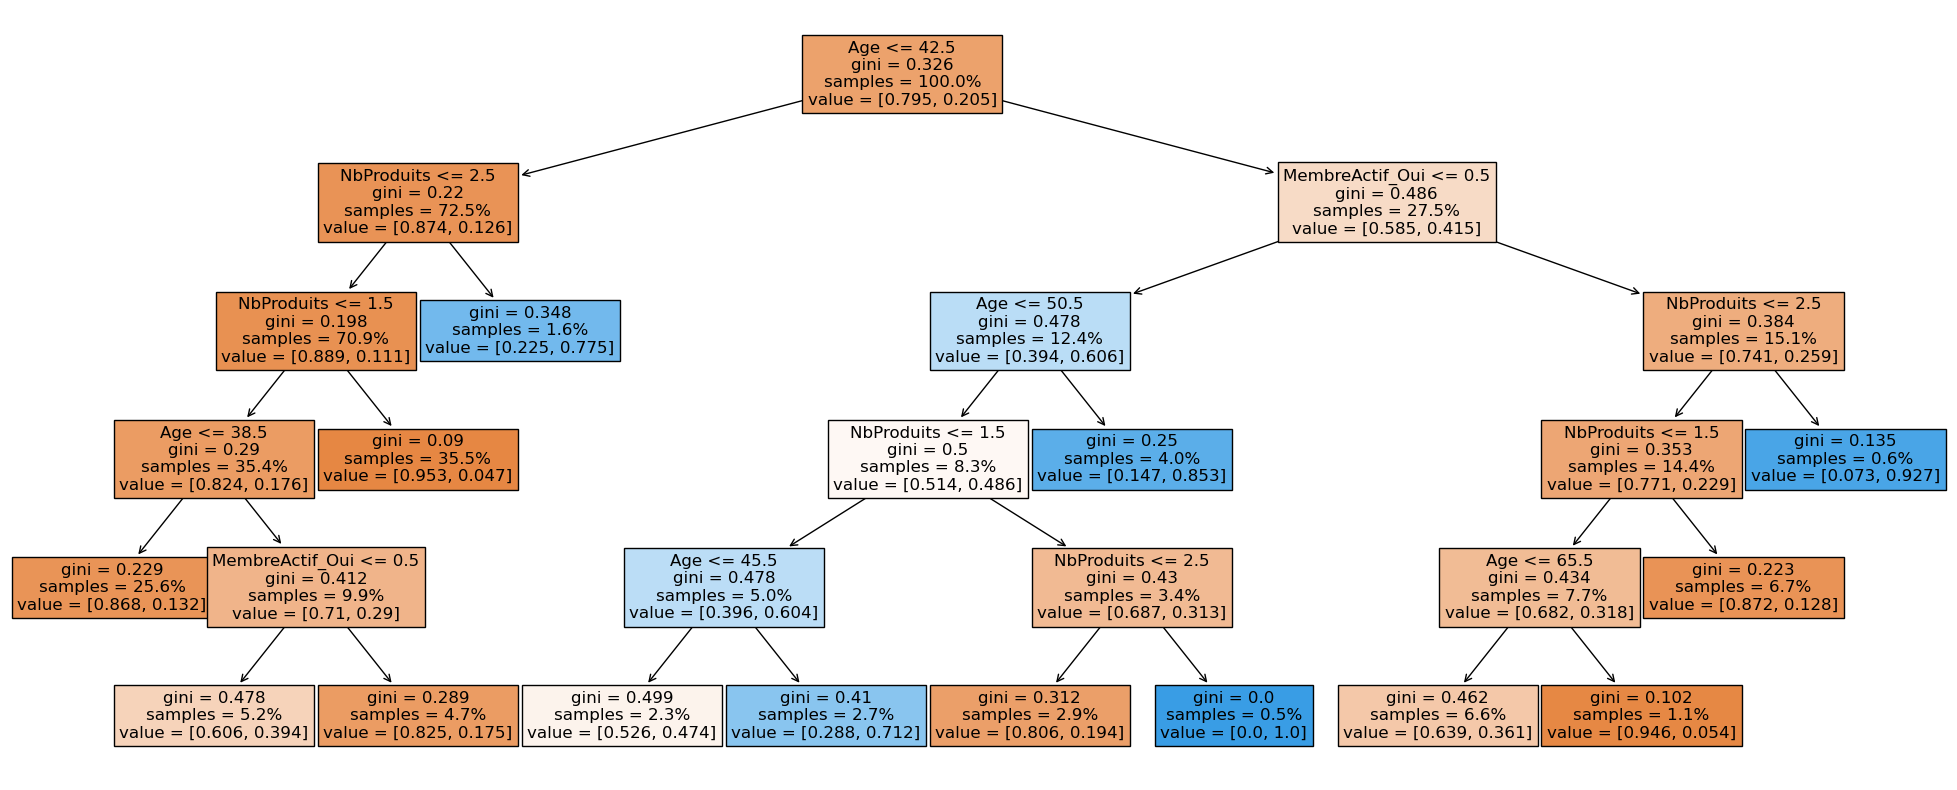

In [30]:
# Spécification de l'arbre de décision - optimisant l'accuracy
print('\n'+'='*50)
mod = "Arbre de décision n°3 - Paramètres optimisant l'accuracy "
print(mod)
print('='*50)
tree_opt = DecisionTreeClassifier(criterion = 'gini', min_samples_leaf = 1, max_leaf_nodes = 14, 
                               max_depth = 6, random_state = my_seed)

# Lancer l'apprentissage du modèle
tree_opt.fit(tree_X_train, y_train)

# Editer le graphique correspondant à l'arbre
X_col = list(tree_X_train.columns)
fig = plt.figure(figsize=(25,10))
arbredec = plot_tree(tree_opt, feature_names=X_col, proportion = True, filled=True, fontsize = 12)
plt.show()

La coupure candidate qui optimise le critère de découpe est la variable "Age". Le seuil pour la première coupure est de 42,5.

On va s'intéresser aux noeuds situées à droite de l'arbre car c'est ici que se trouve les indivudus ayant la plus grande probabilité de quitter la banque.

Les personnes ayant plus de 42,5 ans et étant classés comme étant non actif (selon la présence de flux créditeurs / débiteurs sur le ou les comptes) représentent 12,4 % de notre jeu de données et 60,6 % d'entre eux quittent la banque.

Les personnes ayant plus de 50,5 ans et étant classés comme étant non actif représentent 4 % de notre jeu de données et 85,3 % d'entre eux quittent la banque.

Les personnes ayant un âge supérieur à 42,5 et inférieur ou égal à 50,5 ans, étant classés comme étant non actif, et ayant 1 produit représentent 5 % de notre jeu de données et 60,4 % d'entre eux quittent la banque.

Les personnes ayant un âge supérieur à 45,5 et inférieur ou égal à 50,5 ans, étant classés comme étant non actif, et ayant 1 produit représentent 2,7 % de notre jeu de données et 71,2 % d'entre eux quittent la banque.

Les personnes ayant un âge supérieur à 42,5 et inférieur ou égal à 50,5 ans, étant classés comme étant non actif, et ayant plus de 2 produits représentent 0,5 % de notre jeu de données et 100 % d'entre eux quittent la banque.

Les personnes ayant plus de 42,5 ans, étant classés comme étant actif et ayant plus de 2 produits représentent 0,6 % de notre jeu de données et 92,7 % d'entre eux quittent la banque.

Les personnes ayant un âge inférieur ou égal à 42,5 ans et ayant plus de 2 produits représentent 1,6 % de notre jeu de données et 77,5 % d'entre eux quittent la banque.

Echantillon train
[[5953  888]
 [ 632 1137]]
              precision    recall  f1-score   support

           0       0.90      0.87      0.89      6841
           1       0.56      0.64      0.60      1769

    accuracy                           0.82      8610
   macro avg       0.73      0.76      0.74      8610
weighted avg       0.83      0.82      0.83      8610

Modèle Arbre de décision n°3 - Paramètres optimisant l'accuracy  - Echantillon train - Aire sous la courbe ROC (AUC) : 82.2%
Echantillon test
[[2526  406]
 [ 281  477]]
              precision    recall  f1-score   support

           0       0.90      0.86      0.88      2932
           1       0.54      0.63      0.58       758

    accuracy                           0.81      3690
   macro avg       0.72      0.75      0.73      3690
weighted avg       0.83      0.81      0.82      3690

Modèle Arbre de décision n°3 - Paramètres optimisant l'accuracy  - Echantillon test - Aire sous la courbe ROC (AUC) : 81.6%


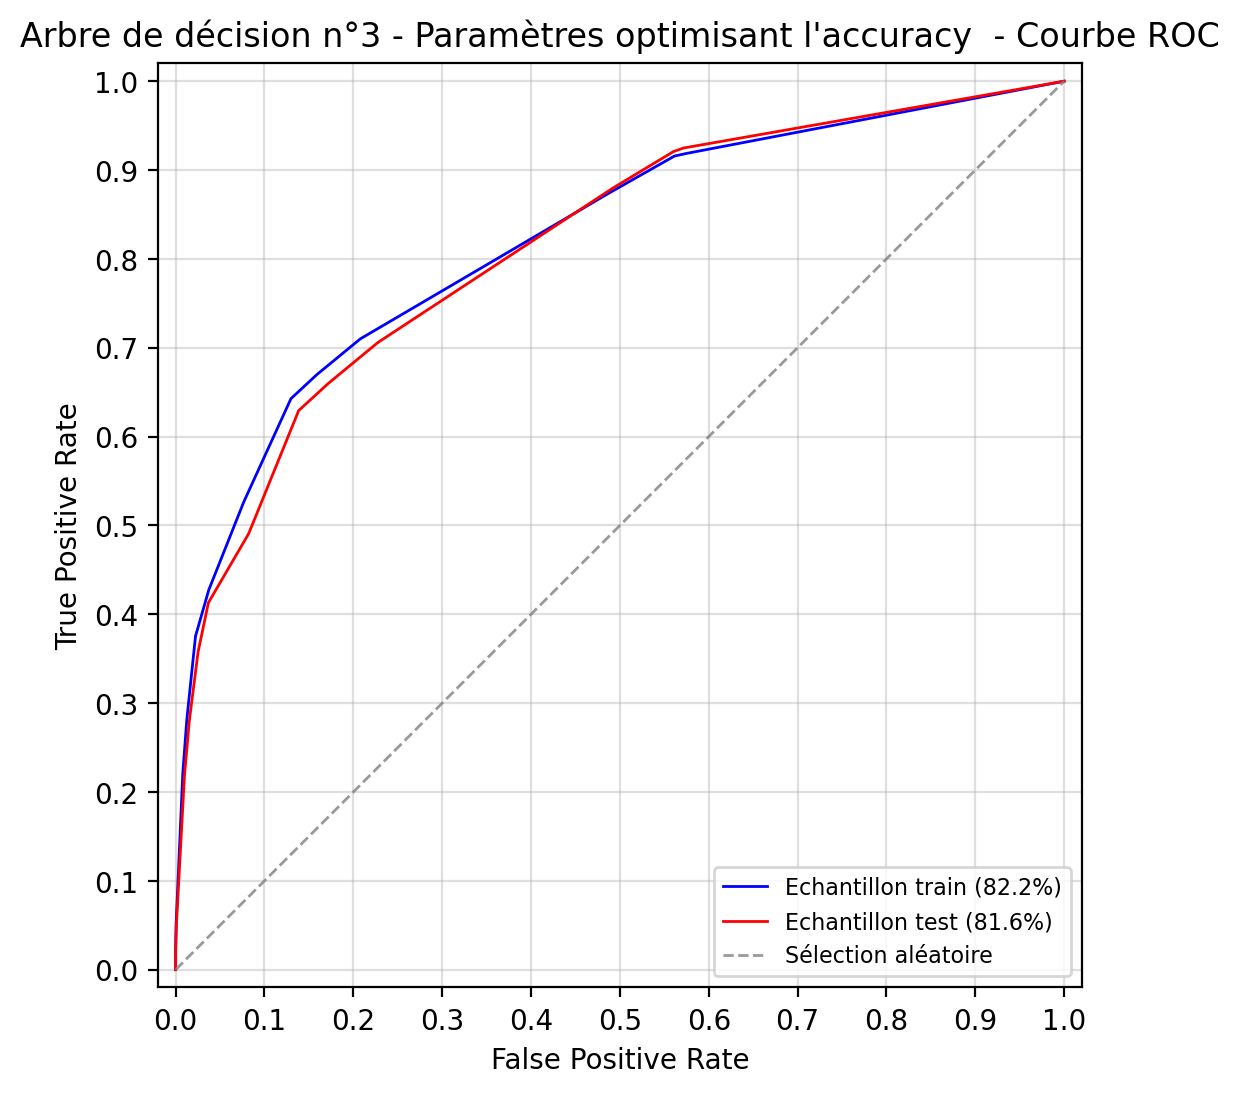

Attention : certains bins sont dupliqués. Ajustement à 6 bins.
[0, 0.04712041884816754, 0.12758620689655173, 0.1316386745347254, 0.17530864197530865, 0.36140350877192984, 0.4742268041237113, 1.0]
   score_bin  target_rate_train  target_rate_test bin_label
0          5               0.81              0.79         1
1          6               0.42              0.38         2
2          7               0.31              0.33         3
3          8               0.18              0.18         4
4          9               0.13              0.15       5-6
5         10               0.06              0.06         7


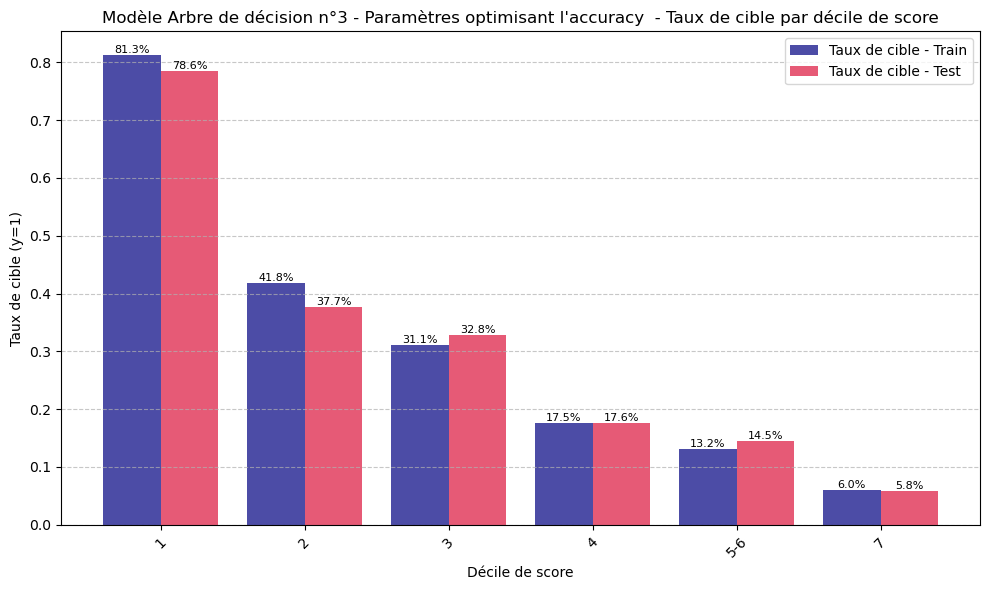

In [31]:
from sklearn.metrics import roc_curve

# Appliquer le modèle à chaque échantillon pour récupérer les probabilités (predict_proba)
proba_train = tree_opt.predict_proba(tree_X_train)[:, 1]
proba_test = tree_opt.predict_proba(tree_X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, proba_test)

dic_roc[mod] = {
    "fpr": fpr,
    "tpr": tpr
}

# Spécification du seuil à utiliser pour la matrice de confusion 
cut_off = y_train.mean()  

# Récupérer les prédictions binaires selon le cut_off
y_pred_train = (proba_train > cut_off).astype('int8')
y_pred_test = (proba_test > cut_off).astype('int8')
    
# Editer les matrices de confusion des échantillons d’apprentissage et de test ainsi que les courbes ROC associées
mat_conf_roc_curve(dic_roc_decisiontree, mod, y_train, y_test, y_pred_train, y_pred_test, proba_train, proba_test)
analyze_target_rate_by_decile(mod, 10, y_train, y_test, proba_train, proba_test)

**Train :**

5 953 clients : Le modèle a bien prédit qu’ils restaient. → Pas d’action nécessaire.

1 137 clients : Le modèle a bien prédit qu’ils partaient. → Mise en place d'actions ciblées (ex : offres de fidélisation).

632 clients : Le modèle a cru qu’ils restaient, mais ils sont partis. → Perte de chiffre d’affaires, opportunité manquée.

888 clients : Le modèle a cru qu’ils partaient, mais ils sont restés. → Ressources gaspillées (ex : appels, promotions inutiles).

Notre accuracy est très bon, il est de 82 %, à voir si il est fiable en interprétant d'autres indicateurs.

Recall : 64 % des clients quittant la banque, ont été correctement identifiés.

Precision : Parmis les clients qui ont été prédit comme quittant la banque, 56 % d'entre eux quittent réellement la banque.

**Test :**

2 526 clients : Le modèle a bien prédit qu’ils restaient. → Pas d’action nécessaire.

477 clients : Le modèle a bien prédit qu’ils partaient. → Mise en place d'actions ciblées (ex : offres de fidélisation).

281 clients : Le modèle a cru qu’ils restaient, mais ils sont partis. → Perte de chiffre d’affaires, opportunité manquée.

406 clients : Le modèle a cru qu’ils partaient, mais ils sont restés. → Ressources gaspillées (ex : appels, promotions inutiles).

Notre accuracy est très bon, il est de 81 %, à voir si il est fiable en interprétant d'autres indicateurs.

Recall : 63 % des clients quittant la banque, ont été correctement identifiés.

Précision : Parmis les clients qui ont été prédit comme quittant la banque, 54 % d'entre eux quittent réellement la banque.

L'aire sous la courbe (AUC) pour l'échantillon train est de 82,2 % et pour l'échantillon test il est de 81,6 %.

L'AUC est donc plus grand pour l'échantillon train, ce qui est normal et la l'écart entre les AUC n'est pas très grande ce qui montre que le modèle ne réalise pas de sur apprentissage sur l'échantillon train.

**Taux de cible par décile de score :**

Un score à été attribué à chaque client, sa probabilité de quitter la banque. Ces scores ont été triés par ordre décroissant, puis découpés en décile afin de visualiser la proportion de client quittant la banque par décile et pour l'échantillon train et test.

On observe une décroissance linéaire des chances de quitter la banque, ce qui prouve que le modèle arrive à bien attribuer des scores aux clients selon sa probabilité de partir.

Sur la 1ère tranche de 10 %, les clients quittent la banque à 81,3 % des cas et on constate une forte chute des clients qui quittent la banque à 41,8 % sur la 2ème tranche de 10 %.

Sur la 3ème tranche de 10 %, les clients quittent la banque à 31,4 % des cas.

**Choix de l'arbre :**

Nous choisissons l'arbre de décison n°3 - Paramètre optimisant l'accuracy, car il obtient de meilleur résultat sur le taux de bien classé (accuracy), sur le pourcentage de client prédit comme quittant la banque et qui la quitte réellement (précision) et pour la capacité à bien séparer les individus de notre variable d'intérêt (AUC).

Néanmoins ce modèle prédit un peu moins bien, avec un écart de 4 % le taux de vrai positif (recall).

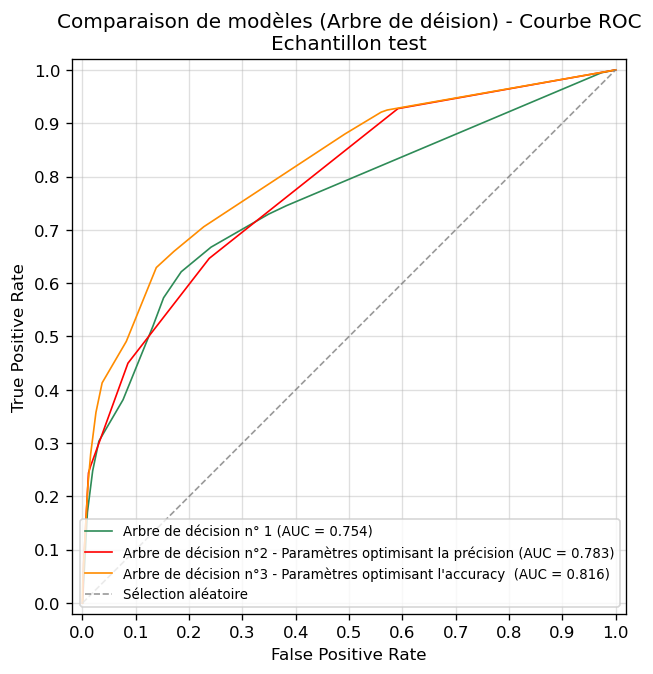

In [32]:
# Graphique de comparaison des arbres de décision - Courbes ROC - Echantillon test
roc_curve_compare(dic_roc_decisiontree, 'Comparaison de modèles (Arbre de déision) - Courbe ROC\nEchantillon test')

#### Choix du seuil pour le meilleur modèle 

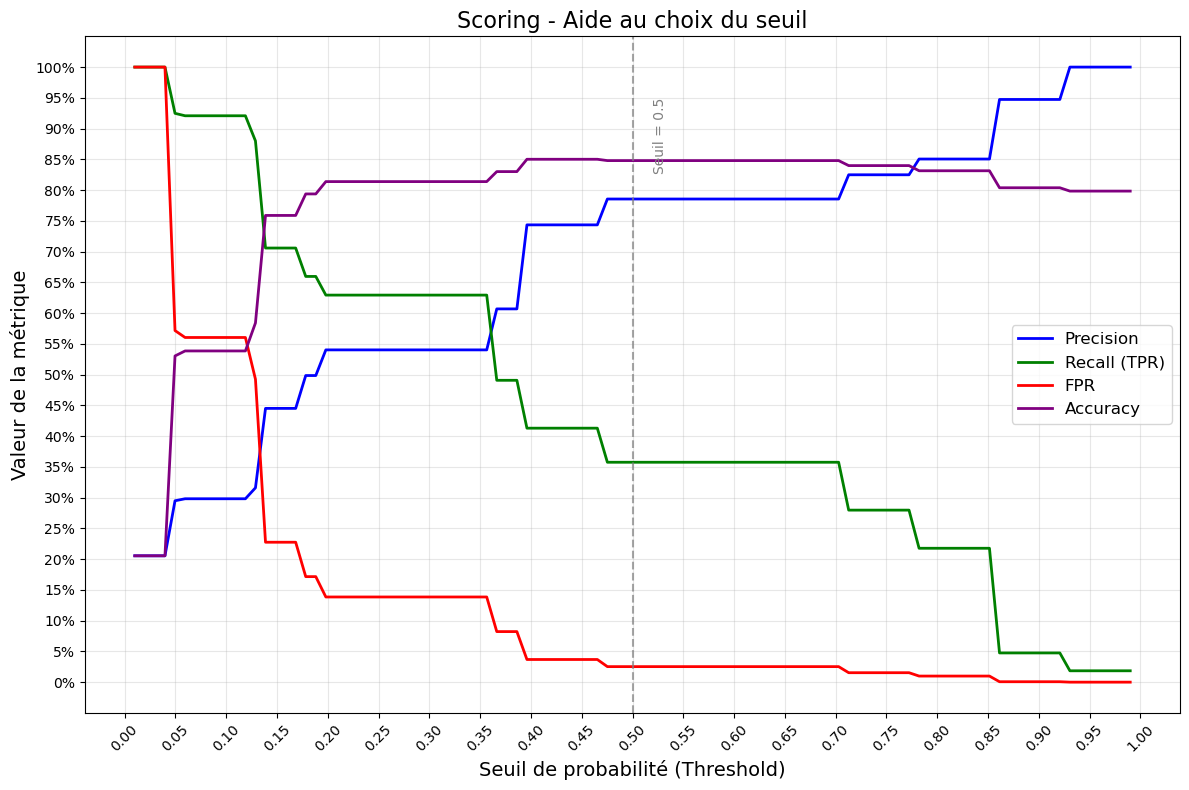

In [33]:
plot_metrics_vs_threshold(y_test, proba_test, n_thresholds=100)

##### Précision

In [34]:
# Spécification du seuil à utiliser pour la matrice de confusion 
cut_off = 0.18

# Récupérer les prédictions binaires selon le cut_off
y_pred_train = (proba_train > cut_off).astype('int8')
y_pred_test = (proba_test > cut_off).astype('int8')
    
# Editer les matrices de confusion des échantillons d’apprentissage et de test ainsi que les courbes ROC associées
mat_conf(mod, y_train, y_test, y_pred_train, y_pred_test, proba_train, proba_test)

Echantillon train
[[5753 1088]
 [ 584 1185]]
              precision    recall  f1-score   support

           0       0.91      0.84      0.87      6841
           1       0.52      0.67      0.59      1769

    accuracy                           0.81      8610
   macro avg       0.71      0.76      0.73      8610
weighted avg       0.83      0.81      0.81      8610

Echantillon test
[[2429  503]
 [ 258  500]]
              precision    recall  f1-score   support

           0       0.90      0.83      0.86      2932
           1       0.50      0.66      0.57       758

    accuracy                           0.79      3690
   macro avg       0.70      0.74      0.72      3690
weighted avg       0.82      0.79      0.80      3690



**Test :**

2 429 clients : Le modèle a bien prédit qu’ils restaient. → Pas d’action nécessaire.

500 clients : Le modèle a bien prédit qu’ils partaient. → Mise en place d'actions ciblées (ex : offres de fidélisation).

258 clients : Le modèle a cru qu’ils restaient, mais ils sont partis. → Perte de chiffre d’affaires, opportunité manquée.

503 clients : Le modèle a cru qu’ils partaient, mais ils sont restés. → Ressources gaspillées (ex : appels, promotions inutiles).

Notre accuracy est très bon, il est de 81 %, à voir si il est fiable en interprétant d'autres indicateurs.

Recall : 66 % des clients quittant la banque, ont été correctement identifiés.

Précision : Parmis les clients qui ont été prédit comme quittant la banque, 50 % d'entre eux quittent réellement la banque.

*Avec un seuil de 0.18, on réussit à identifier plus de clients qui quittent la banque, en revanche on aura tendance à plus se tromper dans l'identifications des clients qui quittent réellement la banque.* 

*On va identifier plus de clients quittant la banque avec un risque plus élévé de mettre en place des actions pour des clients qui restent.*

##### Recall

In [35]:
# Spécification du seuil à utiliser pour la matrice de confusion 
cut_off = 0.36

# Récupérer les prédictions binaires selon le cut_off
y_pred_train = (proba_train > cut_off).astype('int8')
y_pred_test = (proba_test > cut_off).astype('int8')
    
# Editer les matrices de confusion des échantillons d’apprentissage et de test ainsi que les courbes ROC associées
mat_conf(mod, y_train, y_test, y_pred_train, y_pred_test, proba_train, proba_test)

Echantillon train
[[5953  888]
 [ 632 1137]]
              precision    recall  f1-score   support

           0       0.90      0.87      0.89      6841
           1       0.56      0.64      0.60      1769

    accuracy                           0.82      8610
   macro avg       0.73      0.76      0.74      8610
weighted avg       0.83      0.82      0.83      8610

Echantillon test
[[2526  406]
 [ 281  477]]
              precision    recall  f1-score   support

           0       0.90      0.86      0.88      2932
           1       0.54      0.63      0.58       758

    accuracy                           0.81      3690
   macro avg       0.72      0.75      0.73      3690
weighted avg       0.83      0.81      0.82      3690



**Test :**

2 526 clients : Le modèle a bien prédit qu’ils restaient. → Pas d’action nécessaire.

477 clients : Le modèle a bien prédit qu’ils partaient. → Mise en place d'actions ciblées (ex : offres de fidélisation).

281 clients : Le modèle a cru qu’ils restaient, mais ils sont partis. → Perte de chiffre d’affaires, opportunité manquée.

406 clients : Le modèle a cru qu’ils partaient, mais ils sont restés. → Ressources gaspillées (ex : appels, promotions inutiles).

Notre accuracy est très bon, il est de 81 %, à voir si il est fiable en interprétant d'autres indicateurs.

Recall : 63 % des clients quittant la banque, ont été correctement identifiés.

Précision : Parmis les clients qui ont été prédit comme quittant la banque, 54 % d'entre eux quittent réellement la banque.

*Avec un seuil de 0.36, on réussit à identifier moins de clients qui quittent la banque, en revanche on aura moins tendance à  se tromper dans l'identifications des clients qui quittent réellement la banque.* 

*On va identifier moins de clients quittant la banque avec un risque moins élévé de mettre en place des actions pour des clients qui restent.*

### Régression logistique 

In [36]:
# Initialisation d'un dictionnaire pour stocker les courbes ROC des échantillons de test des modèles de régression logistique
dic_roc_reglog = {}

#### Basique


RegLog Basique

Churn ~ ScoreCredit + ZoneGeo + Genre + Age + Anciennete + Solde + NbProduits + CarteCredit + MembreActif + SalaireEstim

                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 8610
Model:                          Logit   Df Residuals:                     8597
Method:                           MLE   Df Model:                           12
Date:                Thu, 15 Jan 2026   Pseudo R-squ.:                  0.1521
Time:                        23:11:49   Log-Likelihood:                -3707.7
converged:                       True   LL-Null:                       -4372.8
Covariance Type:            nonrobust   LLR p-value:                1.461e-277
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.1787      0.081     -2.198    

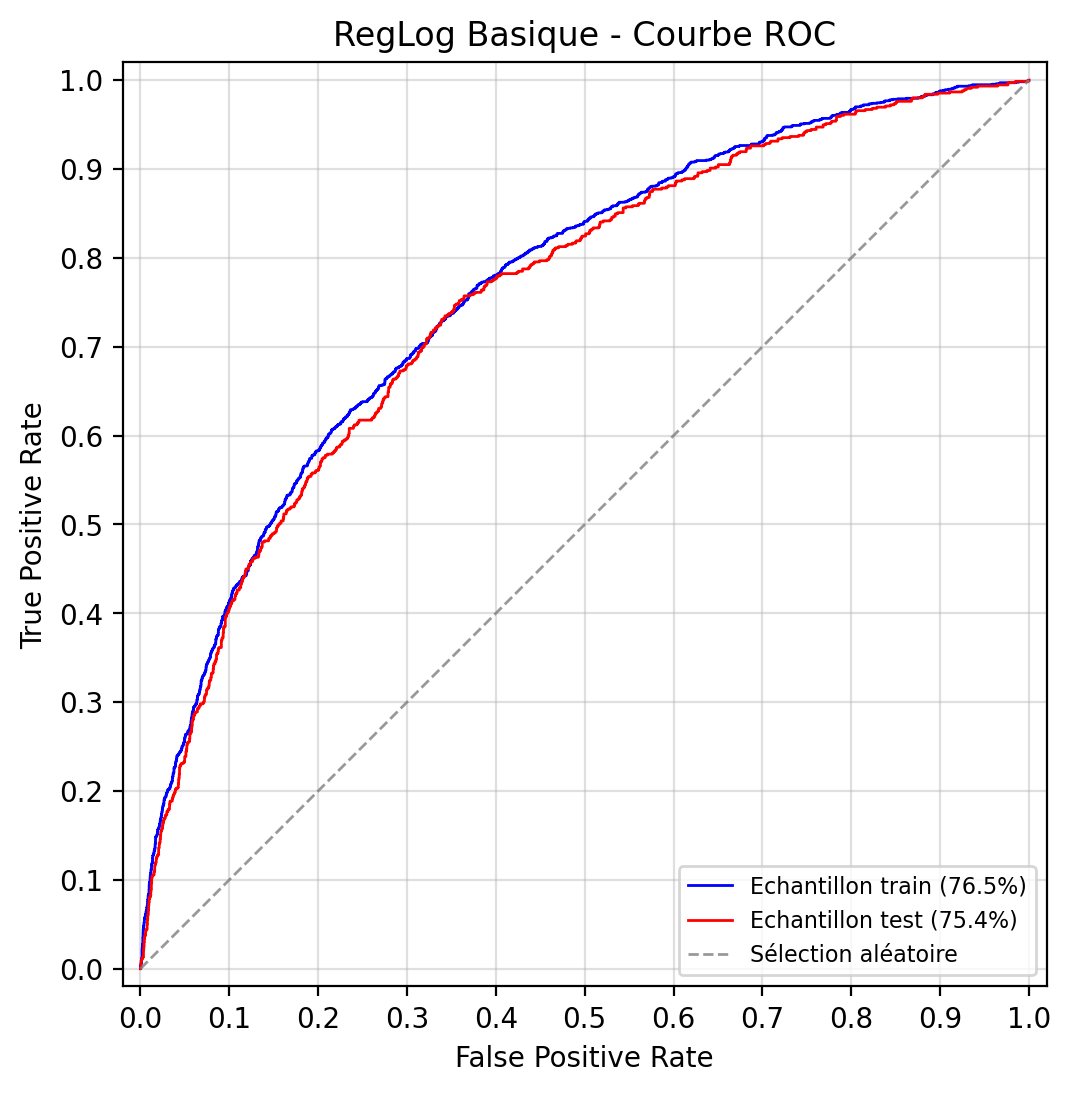

[0, 0.010779668791320493, 0.04744511086976517, 0.0696385880451277, 0.0945497147164476, 0.12424578681729392, 0.15627833128881008, 0.19603085630808062, 0.24641382422204794, 0.31806694586765283, 0.44269969920508023, 0.9749061291114893]
   score_bin  target_rate_train  target_rate_test bin_label
0          1               0.56              0.55         1
1          2               0.41              0.42         2
2          3               0.29              0.26         3
3          4               0.19              0.23         4
4          5               0.19              0.17         5
5          6               0.12              0.13         6
6          7               0.11              0.11         7
7          8               0.09              0.09         8
8          9               0.06              0.07         9
9         10               0.04              0.04        10


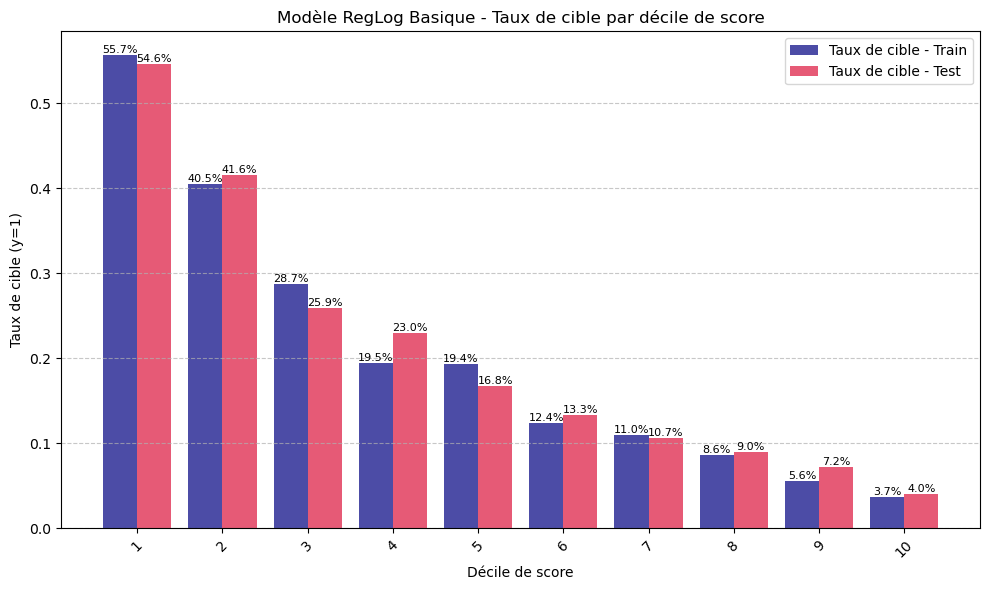

In [37]:
# Standardiser les variables numériques 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
 
X_train_scaled[cont_vars] = scaler.fit_transform(X_train[cont_vars])
X_test_scaled[cont_vars] = scaler.transform(X_test[cont_vars])

mod = 'RegLog Basique'
print('\n'+'='*50)
print(mod)
print('='*50)

# Création d'un dataframe qui réunit X_train et y_train dans un dataframe unique (imposé par StatsModels)
df_train_reglog_cont = pd.concat([y_train, X_train_scaled], axis = 1)

X_cols = list(df_train_reglog_cont.columns)[1:]

# Spécification de la formule du modèle dans formula
formula = "Churn ~ " + ' + '.join(X_cols)
print('\n' + formula + '\n')

# Intialisation du modèle
model = smf.logit(formula, data=df_train_reglog_cont)

# Lancer l'apprentissage du modèle
reg_log = model.fit(method='lbfgs', maxiter=1000, disp = False)

# Edition des coefficients de la régression logistique
print(reg_log.summary())

# Stockage des coefficients dans un dataframe Pandas
summary_coeffs = reg_log.summary2().tables[1].reset_index()

# Appliquer le modèle à chaque échantillon pour récupérer les probabilités (predict_proba)
proba_train = reg_log.predict(df_train_reglog_cont)
proba_test = reg_log.predict(X_test_scaled)

# Spécification du seuil à utiliser pour la matrice de confusion 
cut_off = y_train.mean()  

# Récupérer les prédictions binaires selon le cut_off
y_pred_train = (proba_train > cut_off).astype('int8')
y_pred_test = (proba_test > cut_off).astype('int8')

# Editer les matrices de confusion des échantillons d’apprentissage et de test ainsi que les courbes ROC associées
mat_conf_roc_curve(dic_roc_reglog, mod, y_train, y_test, y_pred_train, y_pred_test, proba_train, proba_test)
analyze_target_rate_by_decile(mod, 10, y_train, y_test, proba_train, proba_test)

Ce premier modèle de régression logistique est très simple, il permet d'observer les résultats que nous pouvons obtenir sans effectuer de modifications sur les variables.  

La courbe ROC est l'indicateur central permettant de déterminer les performances de ce modèle. L'aire sous la courbe (AUC) pour l'échantillon train est de 76,5 % et pour l'échantillon test il est de 75,4 %.
Ce résultat est plutôt bon, il prédit mieux qu'une simple sélection aléatoire. Cependant, nous allons tenter d'améliorer ces performances en entraînant d'autres modèles. 

#### Variables Discrétisées


RegLog QualiOnly
ScoreCredit [406.5, 417.5, 505.5, 509.5, 552.5]
Age [38.5, 42.5, 47.5, 57.5, 65.5]
Anciennete [0.5, 6.5, 7.5, 8.5, 9.5]
Solde [942.1724853515625, 28898.384765625, 45686.1171875, 67921.32421875, 95910.04296875]
NbProduits [1.5, 2.5, 3.5]
SalaireEstim [88707.26953125, 88912.66796875, 89739.8046875, 89880.625, 98272.2578125]
ZoneGeo Churn         0    1
ZoneGeo             
Allemagne  1435  673
Espagne    1699  344
France     3502  698
NR          205   54 Churn        0    1
ZoneGeo            
Allemagne 0.68 0.32
Espagne   0.83 0.17
France    0.83 0.17
NR        0.79 0.21
Genre Churn     0     1
Genre            
Femme  2936  1012
Homme  3905   757 Churn    0    1
Genre          
Femme 0.74 0.26
Homme 0.84 0.16
CarteCredit Churn           0     1
CarteCredit            
Non          1984   519
Oui          4857  1250 Churn          0    1
CarteCredit          
Non         0.79 0.21
Oui         0.80 0.20
MembreActif Churn           0     1
MembreActif            
Non   

Echantillon train
[[5469 1372]
 [ 435 1334]]
              precision    recall  f1-score   support

           0       0.93      0.80      0.86      6841
           1       0.49      0.75      0.60      1769

    accuracy                           0.79      8610
   macro avg       0.71      0.78      0.73      8610
weighted avg       0.84      0.79      0.80      8610

Modèle RegLog QualiOnly - Echantillon train - Aire sous la courbe ROC (AUC) : 85.4%
Echantillon test
[[2326  606]
 [ 212  546]]
              precision    recall  f1-score   support

           0       0.92      0.79      0.85      2932
           1       0.47      0.72      0.57       758

    accuracy                           0.78      3690
   macro avg       0.70      0.76      0.71      3690
weighted avg       0.83      0.78      0.79      3690

Modèle RegLog QualiOnly - Echantillon test - Aire sous la courbe ROC (AUC) : 83.3%


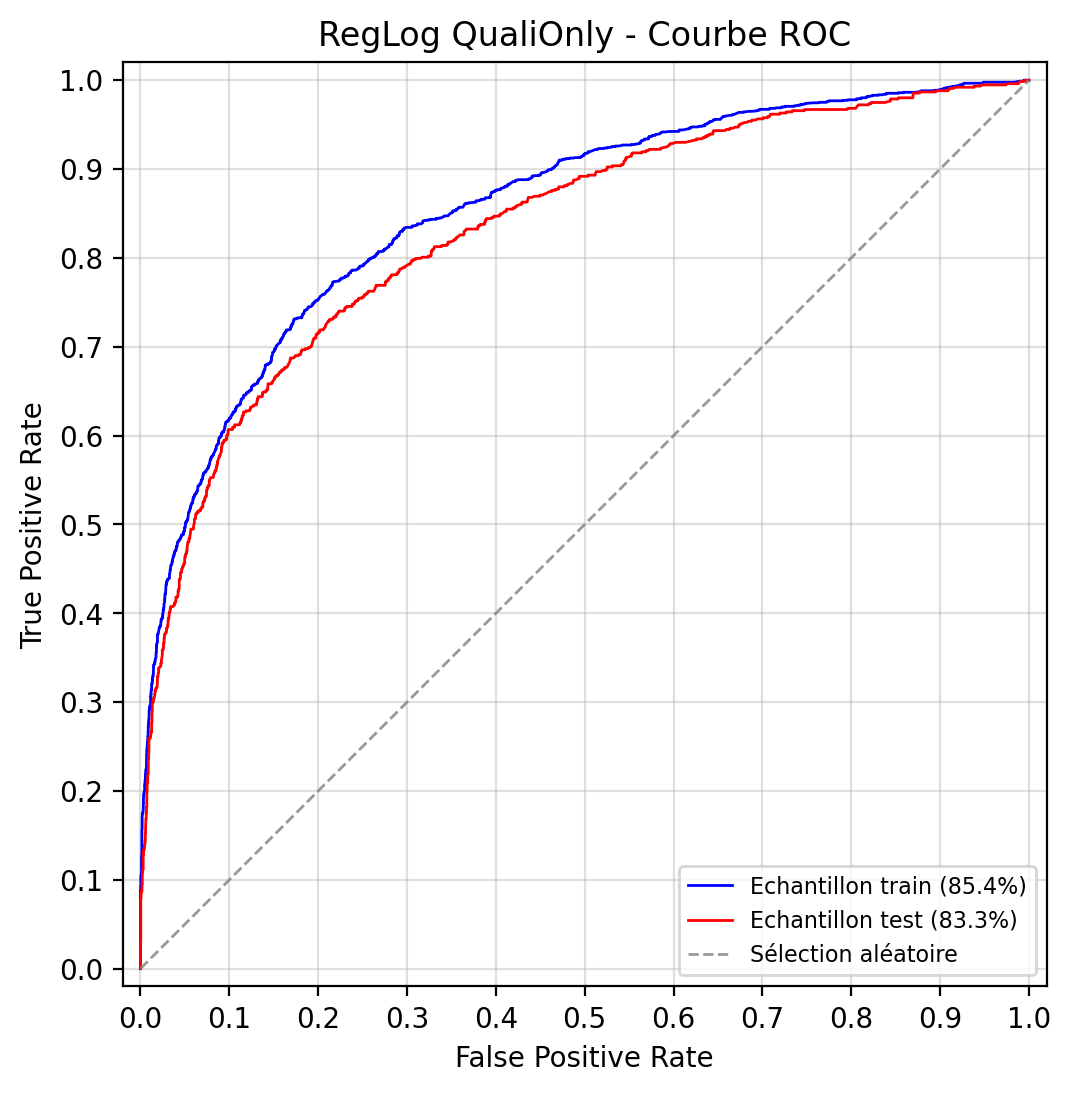

[0, 0.0020981789015085193, 0.02015291565971543, 0.03320716501855121, 0.051299441558269473, 0.07502934189521589, 0.10650837508976965, 0.1463082303489111, 0.21810335974682662, 0.35516014411212443, 0.5792873129340956, 0.9999999999862097]
   score_bin  target_rate_train  target_rate_test bin_label
0          1               0.80              0.78         1
1          2               0.44              0.46         2
2          3               0.28              0.22         3
3          4               0.17              0.17         4
4          5               0.11              0.12         5
5          6               0.10              0.10         6
6          7               0.06              0.08         7
7          8               0.05              0.06         8
8          9               0.03              0.04         9
9         10               0.03              0.03        10


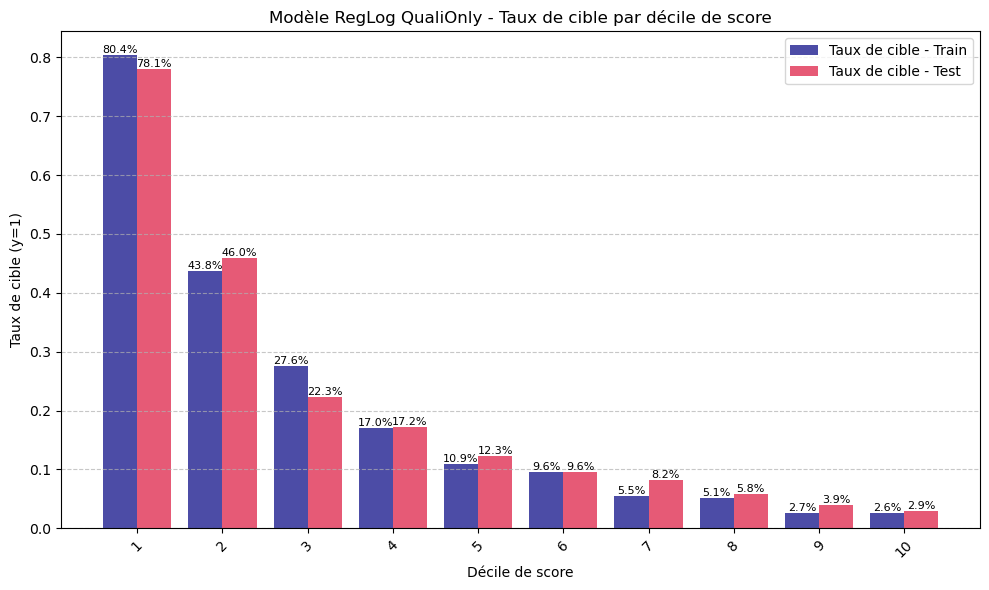

In [38]:
mod = 'RegLog QualiOnly'
print('\n'+'='*50)
print(mod)
print('='*50)

dict_seuils = {}
for v in cont_vars :
    thresholds = find_discretization_thresholds(X_train[v].values, y_train, 6, 10)
    dict_seuils[v]=thresholds
    print(v, thresholds)

# Création des variables discrétisées
for v in cont_vars :       
    X_train[f"{v}_disc"] = X_train[v].apply(lambda x : assign_class(x, thresholds=dict_seuils[v]))
    X_test[f"{v}_disc"] = X_test[v].apply(lambda x : assign_class(x, thresholds=dict_seuils[v]))

# Tableaux croisés entre chaque variable catégorielle explicative et la variable à expliquer
print("="*50)
for v in X_train.drop(columns = cont_vars).columns :
    print(v, pd.crosstab(X_train[v], y_train), pd.crosstab(X_train[v], y_train, normalize = "index"))
print("="*50)

# Création d'un dataframe qui réunit X_train et y_train dans un dataframe unique (imposé par StatsModels)
df_train_reglog = pd.concat([y_train, X_train.drop(columns = cont_vars)], axis = 1)

X_cols = list(df_train_reglog.columns)[1:]

# Spécification de la formule du modèle dans formula
formula = "Churn ~ " + ' + '.join(X_cols)
print('\n' + formula + '\n')

# Intialisation du modèle
model = smf.logit(formula, data=df_train_reglog)

# Lancer l'apprentissage du modèle
reg_log = model.fit(method='lbfgs', maxiter=1000, disp = False)

# Edition des coefficients de la régression logistique
print(reg_log.summary())

# Stockage des coefficients dans un dataframe Pandas
summary_coeffs = reg_log.summary2().tables[1].reset_index()
summary_coeffs.to_excel('reglog_full.xlsx', sheet_name = 'coeff')

# Appliquer le modèle à chaque échantillon pour récupérer les probabilités (predict_proba)
proba_train = reg_log.predict(df_train_reglog)
proba_test = reg_log.predict(X_test)

# Spécification du seuil à utiliser pour la matrice de confusion 
cut_off = y_train.mean() 

# Récupérer les prédictions binaires selon le cut_off
y_pred_train = (proba_train > cut_off).astype('int8')
y_pred_test = (proba_test > cut_off).astype('int8')

# Editer les matrices de confusion des échantillons d’apprentissage et de test ainsi que les courbes ROC associées
mat_conf_roc_curve(dic_roc_reglog, mod, y_train, y_test, y_pred_train, y_pred_test, proba_train, proba_test)
analyze_target_rate_by_decile(mod, 10, y_train, y_test, proba_train, proba_test)

Ce second modèle utilise une nouvelle fois l'ensemble des variables du jeu de données pour tenter de prédire le départ d'un client de la banque. Cependant, l'ensemble des variables continues ont été discrétisés afin d'obtenir des classes et d'effectuer une régression logistique uniquement sur des variables "qualitatives". 

Cette fois-ci, l'AUC est de 85,4 % sur l'échantillon train et 83,3 % sur l'échantillon test. 

Le second modèle est donc nettement plus performant que le premier pour expliquer le départ des clients de la banque. Afin de tenter d'améliorer ces résultats et simplifier le modèle, nous allons conserver uniquement les variables avec une probabilité critique significative, c'est à dire inférieure à 0.05. 

En regardant les résultats, on constate que la variable "Nb produits semble intéressante pour expliquer le départ des clients mais l'une de ses modalités n'est pas significative. Nous allons donc la recoder afin de tenter d'obtenir une probabilité critique significative pour l'ensemble des classes de cette variable. 

#### Recodage du Nb Produits

In [39]:
# Transformation de la variable "Nb produits"
X_train["NbProduits_disc"] = X_train["NbProduits"].map({
    1: "1",
    2: "2",
    3: "3 et +",
    4 : "3 et +"
}).astype('category')
 
X_test["NbProduits_disc"] = X_test["NbProduits"].map({
    1: "1",
    2: "2",
    3: "3 et +",
    4 : "3 et +"
}).astype('category')
 
X_train = X_train.drop(columns=["NbProduits"])
X_test  = X_test.drop(columns=["NbProduits"])

# Tableaux croisés entre chaque variable catégorielle explicative et la variable à expliquer
cont_vars = ['ScoreCredit','Age','Anciennete','Solde','SalaireEstim']
print("="*50)
for v in X_train.drop(columns = cont_vars).columns :
    print(v, pd.crosstab(X_train[v], y_train), pd.crosstab(X_train[v], y_train, normalize = "index"))
print("="*50)

# Création d'un dataframe qui réunit X_train et y_train dans un dataframe unique (imposé par StatsModels)
df_train_reglog = pd.concat([y_train, X_train.drop(columns = cont_vars)], axis = 1)

X_cols = list(df_train_reglog.columns)[1:]

ZoneGeo Churn         0    1
ZoneGeo             
Allemagne  1435  673
Espagne    1699  344
France     3502  698
NR          205   54 Churn        0    1
ZoneGeo            
Allemagne 0.68 0.32
Espagne   0.83 0.17
France    0.83 0.17
NR        0.79 0.21
Genre Churn     0     1
Genre            
Femme  2936  1012
Homme  3905   757 Churn    0    1
Genre          
Femme 0.74 0.26
Homme 0.84 0.16
CarteCredit Churn           0     1
CarteCredit            
Non          1984   519
Oui          4857  1250 Churn          0    1
CarteCredit          
Non         0.79 0.21
Oui         0.80 0.20
MembreActif Churn           0     1
MembreActif            
Non          3050  1157
Oui          3791   612 Churn          0    1
MembreActif          
Non         0.72 0.28
Oui         0.86 0.14
ScoreCredit_disc Churn                 0     1
ScoreCredit_disc             
0. <= 406.5           0    21
1. ]406.5, 417.5]    19     1
2. ]417.5, 505.5]   457   133
3. ]505.5, 509.5]    56     4
4. ]509.5, 552.

#### Sélection de variables 


RegLog avec sélection de variables

Churn ~ ZoneGeo + Genre + MembreActif + Age_disc + NbProduits_disc

                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 8610
Model:                          Logit   Df Residuals:                     8597
Method:                           MLE   Df Model:                           12
Date:                Thu, 15 Jan 2026   Pseudo R-squ.:                  0.2977
Time:                        23:11:52   Log-Likelihood:                -3071.2
converged:                       True   LL-Null:                       -4372.8
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      -0.5510      0.084     -6.574      0.000

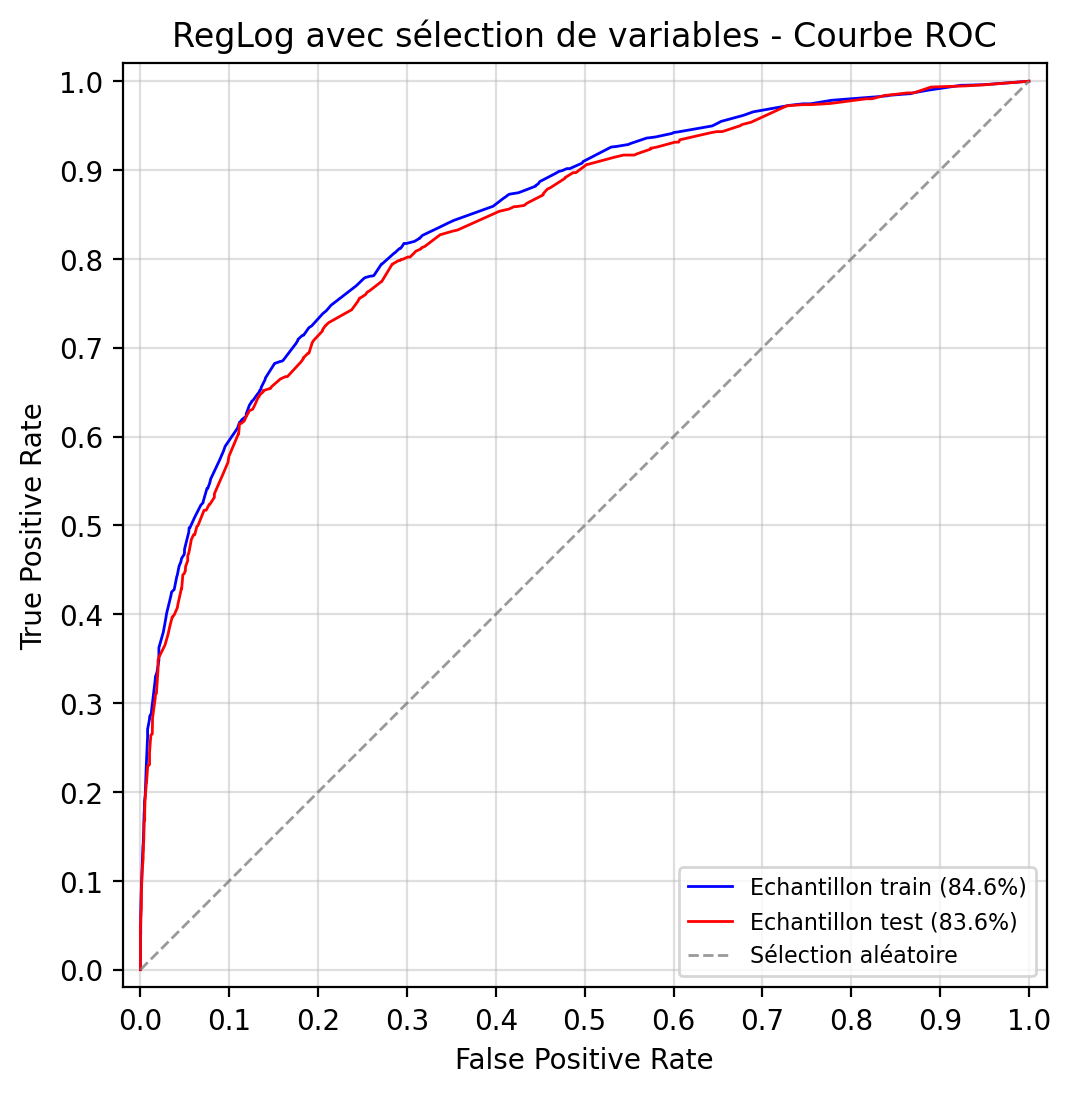

[0, 0.010957007139927392, 0.01171926828422017, 0.02088541932154476, 0.03126124043606648, 0.0333883494197918, 0.04532229900339394, 0.05486350819661955, 0.0594830525597239, 0.07867846665669734, 0.09909480047726868, 0.11855043020798794, 0.12244823316674451, 0.1512357287206575, 0.19099863987577387, 0.21177046444588782, 0.2541380040773274, 0.3656219126347744, 0.4240021368765665, 0.5807828699159475, 0.7580492398422141, 0.9932876860456353]
    score_bin  target_rate_train  target_rate_test bin_label
0           1               0.90              0.91         1
1           2               0.70              0.67         2
2           3               0.50              0.49         3
3           4               0.37              0.37         4
4           5               0.30              0.30         5
5           6               0.23              0.22         6
6           7               0.19              0.18         7
7           8               0.18              0.21         8
8           9 

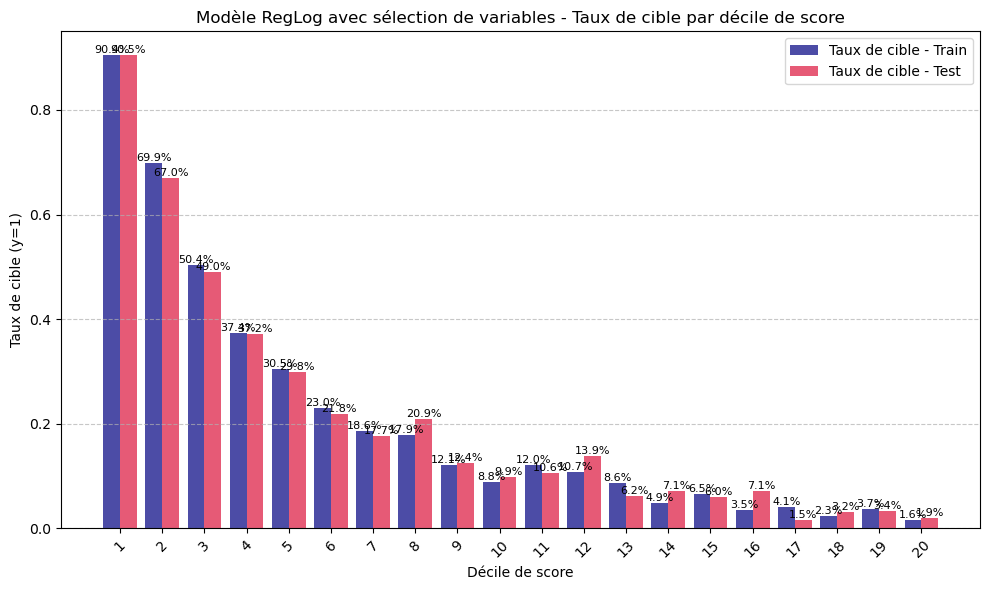

In [40]:
mod = 'RegLog avec sélection de variables'
print('\n'+'='*50)
print(mod)
print('='*50)
formula2 = "Churn ~ ZoneGeo + Genre + MembreActif + Age_disc + NbProduits_disc"
print('\n' + formula2 + '\n')

# Intialisation du modèle
model2 = smf.logit(formula2, data=df_train_reglog)

# Lancer l'apprentissage du modèle
reg_log2 = model2.fit(method='lbfgs', maxiter=1000, disp = False)

# Edition des coefficients de la régression logistique
print(reg_log2.summary())

# Stockage des coefficients dans un dataframe Pandas
summary_coeffs2 = reg_log2.summary2().tables[1].reset_index()

# Appliquer le modèle à chaque échantillon pour récupérer les probabilités (predict_proba)
proba_train = reg_log2.predict(df_train_reglog)
proba_test = reg_log2.predict(X_test)

# Spécification du seuil à utiliser pour la matrice de confusion 
cut_off = y_train.mean()

# Récupérer les prédictions binaires selon le cut_off
y_pred_train = (proba_train > cut_off).astype('int8')
y_pred_test = (proba_test > cut_off).astype('int8')

# Editer les matrices de confusion des échantillons d’apprentissage et de test ainsi que les courbes ROC associées
mat_conf_roc_curve(dic_roc_reglog, mod, y_train, y_test, y_pred_train, y_pred_test, proba_train, proba_test)
analyze_target_rate_by_decile(mod, 20, y_train, y_test, proba_train, proba_test)

Ce troisième modèle utilise donc les variables les plus pertinentes pour tenter d'expliquer le départ d'un client de la banque. 

On observe que la choix des variables avec une probabilité critique significative semble pertinent car on parvient une nouvelle fois à augmenter notre aire sous la courbe. 

A présent, notre AUC est de 84,6 % sur l'échantillon train et 83,6 % sur l'échantillon test. L'AUC a donc légèrement diminuée sur l'échantillon train mais elle s'est améliorée pour l'échantillon test. 

Les résultats de notre modèle sont déjà très satisfaisants mais nous souhaitons aller plus loin en ajoutant des interactions entre les variables. L'objectif est de mieux capturer les relations complexes dans les données en modélisant des effets combinés qui pourraient éventuellement augmenter la précision du modèle et sa capacité de prédiction. 


#### Avec interactions


RegLog avec interactions

Churn ~ ZoneGeo + Genre + MembreActif + Age_disc + NbProduits_disc + Age_disc * MembreActif + Solde_disc * NbProduits_disc

                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 8610
Model:                          Logit   Df Residuals:                     8577
Method:                           MLE   Df Model:                           32
Date:                Thu, 15 Jan 2026   Pseudo R-squ.:                  0.3313
Time:                        23:11:53   Log-Likelihood:                -2924.2
converged:                       True   LL-Null:                       -4372.8
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------

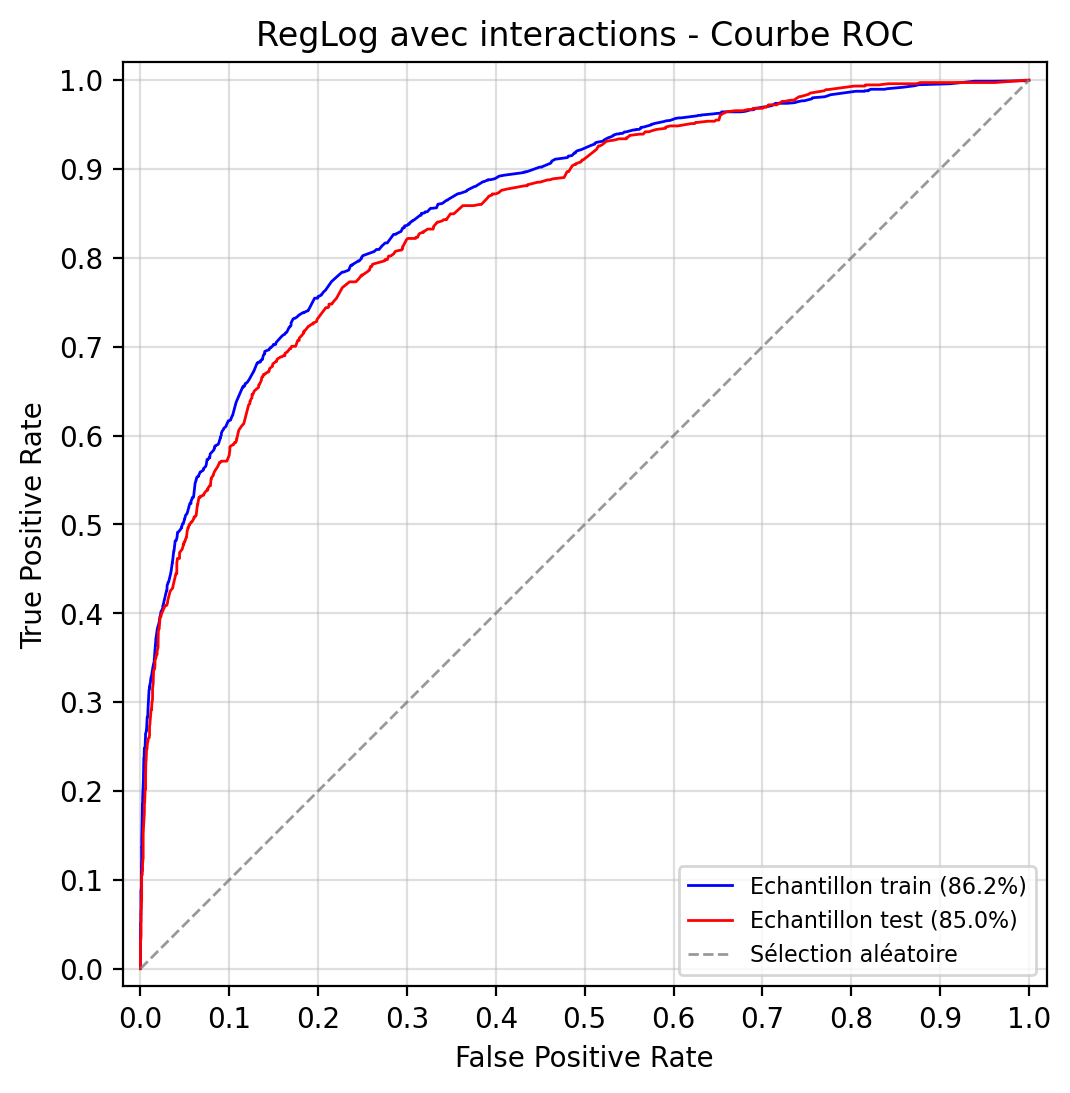

[0, 0.007093407303996426, 0.014918574145235865, 0.029693080496303606, 0.05130789175068226, 0.07550336267483862, 0.10524942363075218, 0.150857253362989, 0.20578276681418173, 0.3345931356766832, 0.5591067465326361, 0.9998289514486188]
   score_bin  target_rate_train  target_rate_test bin_label
0          1               0.82              0.82         1
1          2               0.43              0.40         2
2          3               0.27              0.28         3
3          4               0.18              0.18         4
4          5               0.13              0.13         5
5          6               0.08              0.11         6
6          7               0.06              0.06         7
7          8               0.03              0.06         8
8          9               0.03              0.03         9
9         10               0.01              0.01        10


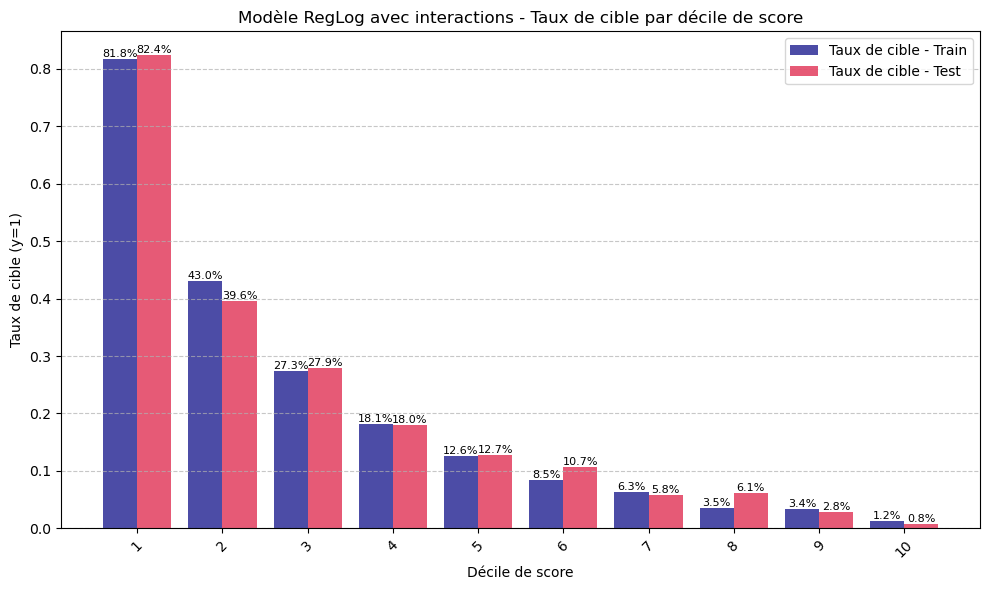

In [41]:
mod = 'RegLog avec interactions'
print('\n'+'='*50)
print(mod)
print('='*50)
formula3 = formula2 + ' + Age_disc * MembreActif + Solde_disc * NbProduits_disc'
print('\n' + formula3 + '\n')
 
# Intialisation du modèle
model3 = smf.logit(formula3, data=df_train_reglog)
 
# Lancer l'apprentissage du modèle
reg_log3 = model3.fit(method='lbfgs', maxiter=1000, disp = False)

# Edition des coefficients de la régression logistique
print(reg_log3.summary())

# Stockage des coefficients dans un dataframe Pandas
summary_coeffs3 = reg_log3.summary2().tables[1].reset_index()
 
# Appliquer le modèle à chaque échantillon pour récupérer les probabilités (predict_proba)
proba_train = reg_log3.predict(df_train_reglog) 
proba_test = reg_log3.predict(X_test)

fpr, tpr, _ = roc_curve(y_test, proba_test)

dic_roc[mod] = {
    "fpr": fpr,
    "tpr": tpr
}

# Spécification du seuil à utiliser pour la matrice de confusion 
cut_off = y_train.mean()  

# Récupérer les prédictions binaires selon le cut_off
y_pred_train = (proba_train > cut_off).astype('int8')
y_pred_test = (proba_test > cut_off).astype('int8')
 
# Editer les matrices de confusion des échantillons d’apprentissage et de test ainsi que les courbes ROC associées
mat_conf_roc_curve(dic_roc_reglog, mod, y_train, y_test, y_pred_train, y_pred_test, proba_train, proba_test)
analyze_target_rate_by_decile(mod, 10, y_train, y_test, proba_train, proba_test)

#### Evaluation globale du modèle

Le modèle de régression logistique avec interactions présente une capacité de discrimination correcte, avec une AUC de 86,2 % sur l’échantillon d’apprentissage et de 85,0 % sur l’échantillon de test. La proximité entre ces deux valeurs indique une bonne généralisation et l’absence de sur-apprentissage marqué. La courbe ROC sur le jeu de test reste nettement au-dessus de la diagonale aléatoire, confirmant que le score produit par le modèle est informatif.

**Significativité des variables et des interactions**

L’analyse des coefficients montre que plusieurs variables explicatives sont hautement significatives (p-value < 0,05), notamment :
- l’âge (via les classes discrétisées),
- le nombre de produits détenus,
- la zone géographique,
- le solde,
- ainsi que certaines interactions clés (âge × statut actif, solde × nombre de produits).

Ces interactions enrichissent le modèle en capturant des effets combinés pertinents d’un point de vue métier. En revanche, certaines interactions présentent des p-values élevées, suggérant un apport limité. Elles pourraient être supprimées dans une version plus parcimonieuse du modèle sans perte majeure de performance.

**Analyse des matrices de confusion**
Sur l’échantillon d’apprentissage, le modèle identifie correctement la majorité des individus, avec une accuracy d’environ 80 %. Sur l’échantillon de test, les performances restent stables (accuracy ≈ 79 %), confirmant la robustesse du modèle.

Concernant la classe churn :
- le rappel est d’environ 73 %, ce qui signifie que près de trois churners sur quatre sont correctement détectés ;
- la précision est plus faible (≈ 49 %), traduisant un nombre non négligeable de faux positifs.

Ce comportement est cohérent avec un objectif de détection prioritaire des churners, quitte à accepter davantage de clients non churn ciblés.

**Analyse par déciles de score**

L’analyse par déciles met en évidence une bonne capacité de ranking :
- le premier décile concentre plus de 80 % de churners, aussi bien sur le train que sur le test ;
- le taux de churn décroît de manière quasi monotone au fil des déciles ;
- les derniers déciles présentent des taux très faibles, proches de zéro.

Cette structure confirme que le score est exploitable opérationnellement, notamment pour prioriser les actions de rétention sur les clients les plus à risque.

**Évaluation globale et positionnement du modèle**
En synthèse, la régression logistique avec interactions constitue un modèle robuste, interprétable et cohérent, offrant :
- une discrimination satisfaisante,
- une bonne stabilité entre apprentissage et test,
- une lecture claire des facteurs de churn via les coefficients,
- et un score bien ordonné pour un usage métier.

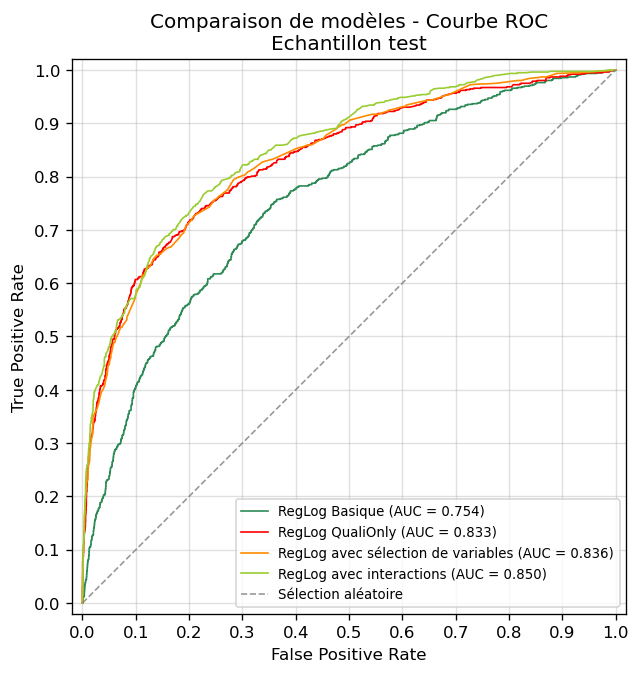

In [42]:
# Graphique de comparaison des régressions losgistique - Courbes ROC - Echantillon test
roc_curve_compare(dic_roc_reglog, 'Comparaison de modèles - Courbe ROC\nEchantillon test')

Le schéma permet de visualiser l'ensemble des courbes ROC pour chaque modèle de régression logistique. On constate bien que c'est celui avec les interactions qui semble être le meilleur. 
Pour la suite, nous allons utiliser uniquement ce modèle et tester différents seuils afin d'observer comment cela permet d'améliorer notre outil pour correspondre aux attentes d'équipes marketing.

#### Choix du seuil pour le meilleur modèle

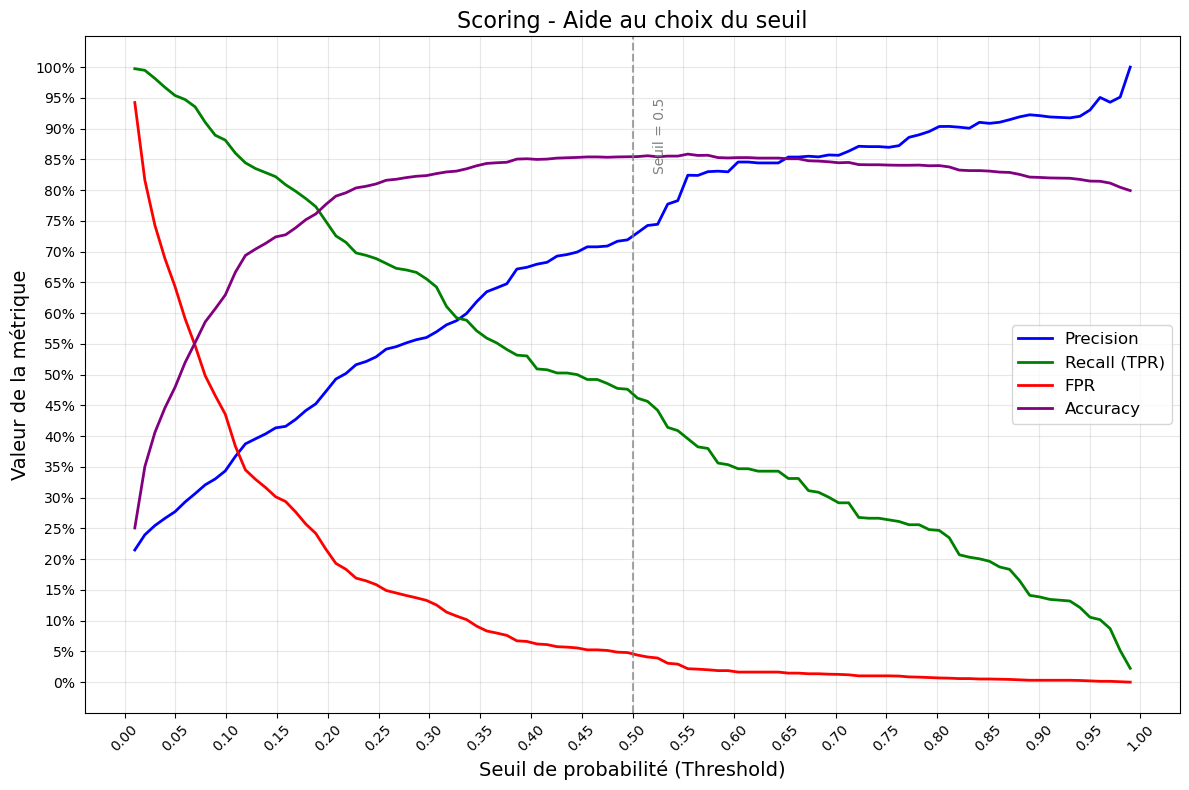

In [43]:
plot_metrics_vs_threshold(y_test, proba_test, n_thresholds=100)

In [44]:
mod = 'RegLog avec sélection du seuil à 0.22'
print('\n'+'='*50)
print(mod)
print('='*50)
print('\n' + formula3 + '\n')

# Spécification du seuil à utiliser pour la matrice de confusion 
cut_off = 0.22

# Récupérer les prédictions binaires selon le cut_off
y_pred_train = (proba_train > cut_off).astype('int8')
y_pred_test = (proba_test > cut_off).astype('int8')

# Editer les matrices de confusion des échantillons d’apprentissage et de test ainsi que les courbes ROC associées
mat_conf(mod, y_train, y_test, y_pred_train, y_pred_test, proba_train, proba_test)


RegLog avec sélection du seuil à 0.22

Churn ~ ZoneGeo + Genre + MembreActif + Age_disc + NbProduits_disc + Age_disc * MembreActif + Solde_disc * NbProduits_disc

Echantillon train
[[5683 1158]
 [ 489 1280]]
              precision    recall  f1-score   support

           0       0.92      0.83      0.87      6841
           1       0.53      0.72      0.61      1769

    accuracy                           0.81      8610
   macro avg       0.72      0.78      0.74      8610
weighted avg       0.84      0.81      0.82      8610

Echantillon test
[[2408  524]
 [ 222  536]]
              precision    recall  f1-score   support

           0       0.92      0.82      0.87      2932
           1       0.51      0.71      0.59       758

    accuracy                           0.80      3690
   macro avg       0.71      0.76      0.73      3690
weighted avg       0.83      0.80      0.81      3690



In [45]:
mod = 'RegLog avec sélection du seuil à 0.34'
print('\n'+'='*50)
print(mod)
print('='*50)
print('\n' + formula3 + '\n')

# Spécification du seuil à utiliser pour la matrice de confusion 
cut_off = 0.34 

# Récupérer les prédictions binaires selon le cut_off
y_pred_train = (proba_train > cut_off).astype('int8')
y_pred_test = (proba_test > cut_off).astype('int8')

# Editer les matrices de confusion des échantillons d’apprentissage et de test ainsi que les courbes ROC associées
mat_conf(mod, y_train, y_test, y_pred_train, y_pred_test, proba_train, proba_test)


RegLog avec sélection du seuil à 0.34

Churn ~ ZoneGeo + Genre + MembreActif + Age_disc + NbProduits_disc + Age_disc * MembreActif + Solde_disc * NbProduits_disc

Echantillon train
[[6227  614]
 [ 712 1057]]
              precision    recall  f1-score   support

           0       0.90      0.91      0.90      6841
           1       0.63      0.60      0.61      1769

    accuracy                           0.85      8610
   macro avg       0.76      0.75      0.76      8610
weighted avg       0.84      0.85      0.84      8610

Echantillon test
[[2639  293]
 [ 319  439]]
              precision    recall  f1-score   support

           0       0.89      0.90      0.90      2932
           1       0.60      0.58      0.59       758

    accuracy                           0.83      3690
   macro avg       0.75      0.74      0.74      3690
weighted avg       0.83      0.83      0.83      3690



In [46]:
mod = 'RegLog avec sélection du seuil à 0.45'
print('\n'+'='*50)
print(mod)
print('='*50)
print('\n' + formula3 + '\n')

# Spécification du seuil à utiliser pour la matrice de confusion 
cut_off = 0.45

# Récupérer les prédictions binaires selon le cut_off
y_pred_train = (proba_train > cut_off).astype('int8')
y_pred_test = (proba_test > cut_off).astype('int8')

# Editer les matrices de confusion des échantillons d’apprentissage et de test ainsi que les courbes ROC associées
mat_conf(mod, y_train, y_test, y_pred_train, y_pred_test, proba_train, proba_test)


RegLog avec sélection du seuil à 0.45

Churn ~ ZoneGeo + Genre + MembreActif + Age_disc + NbProduits_disc + Age_disc * MembreActif + Solde_disc * NbProduits_disc

Echantillon train
[[6468  373]
 [ 850  919]]
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      6841
           1       0.71      0.52      0.60      1769

    accuracy                           0.86      8610
   macro avg       0.80      0.73      0.76      8610
weighted avg       0.85      0.86      0.85      8610

Echantillon test
[[2771  161]
 [ 379  379]]
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      2932
           1       0.70      0.50      0.58       758

    accuracy                           0.85      3690
   macro avg       0.79      0.72      0.75      3690
weighted avg       0.84      0.85      0.84      3690



### Forêt Aléatoire

In [47]:
# Initialisation d'un dictionnaire pour stocker les courbes ROC des échantillons de test des forêts aléatoires
dic_roc_rf = {}

#### Choix des meilleurs paramètres

 **Optimisation du modèle de forêt aléatoire**

Afin d’évaluer si une forêt aléatoire pouvait améliorer la détection des clients en situation de churn, nous avons entraîné un modèle de Random Forest, reconnu pour sa robustesse et sa capacité à modéliser des relations non linéaires complexes.

Cependant, les performances de cet algorithme dépendent fortement du choix des hyperparamètres. Un réglage inadéquat peut conduire soit à un sur-apprentissage, soit à un modèle insuffisamment discriminant. Après analyse de la littérature et des bonnes pratiques en scoring, il apparaît que certains paramètres ont un impact bien plus déterminant que d’autres.

**Stratégie de réglage des hyperparamètres**

Plutôt que d’explorer toutes les combinaisons possibles (recherche exhaustive coûteuse et peu interprétable), nous avons adopté une approche séquentielle et structurée. Les hyperparamètres ont été testés un par un, selon leur ordre d’impact attendu, en conservant à chaque étape la valeur offrant les meilleures performances sur l’échantillon de validation. Cette méthode permet :
- de mieux comprendre l’effet de chaque paramètre,
- de limiter le risque de sur-ajustement,
- d’aboutir à un modèle plus stable et généralisable.

**Ordre de test des hyperparamètres**

- Nombre d’arbres (n_estimators) : Testé sur plusieurs valeurs (300 à 1200), ce paramètre influence la stabilité du modèle. Un nombre élevé d’arbres réduit la variance, jusqu’à atteindre un seuil de saturation.

- Nombre de variables candidates à chaque division (max_features) : Ce paramètre joue un rôle clé dans la régulation du sur-apprentissage. Différentes stratégies (racine carrée, logarithme, proportions fixes) ont été comparées.

- Taille minimale des feuilles (min_samples_leaf) : Paramètre crucial pour la généralisation. En imposant un nombre minimal d’observations par feuille, le modèle évite des divisions trop spécifiques et améliore nettement ses performances sur les données de test.

- Profondeur maximale des arbres (max_depth) : Ce paramètre permet de contrôler la complexité des arbres et d’éviter des structures trop profondes, souvent responsables d’un sur-apprentissage.

- Pondération des classes (class_weight) : Dans un contexte de churn, où les classes sont déséquilibrées, ce paramètre est essentiel pour réduire les faux négatifs, quitte à augmenter légèrement le nombre de faux positifs.

**Conclusion**

Cette stratégie de réglage progressif nous a permis d’identifier une forêt aléatoire optimisée, offrant un compromis satisfaisant entre capacité de discrimination, robustesse et généralisation.
Elle garantit également une meilleure interprétabilité du processus de modélisation, un point essentiel dans un contexte bancaire et décisionnel.

#### Paramètres optimaux

In [48]:
# ================================
# Étude de l'impact du nombre d'arbres (n_estimators)
# ================================

# Valeurs testées pour le nombre d'arbres
# Objectif : évaluer la stabilité du modèle et identifier un éventuel point de saturation
n_estimators_list = [100, 200, 300, 500, 800, 1200]

# Validation croisée stratifiée (conserve la proportion de churners dans chaque fold)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=my_seed)

results = []

for n in n_estimators_list:
    
    # Définition du modèle Random Forest
    # Les autres hyperparamètres sont volontairement fixés
    # afin d'isoler l'effet du nombre d'arbres
    rf = RandomForestClassifier(
        n_estimators=n,
        max_depth=None,              # pas de contrainte de profondeur à ce stade
        min_samples_leaf=5,          # régularisation légère pour limiter le sur-apprentissage
        max_features="sqrt",         # choix standard et robuste
        class_weight="balanced",     # prise en compte du déséquilibre des classes (churn)
        random_state=42,
        n_jobs=-1
    )
    
    # Entraînement du modèle sur l'échantillon d'apprentissage
    rf.fit(tree_X_train, y_train)
    
    # Calcul de l'AUC sur l'échantillon d'apprentissage (mesure la capacité maximale de discrimination du modèle)
    auc_train = roc_auc_score(
        y_train,
        rf.predict_proba(tree_X_train)[:, 1]
    )
    
    # Calcul de l'AUC sur l'échantillon de test (évalue la capacité de généralisation)
    auc_test = roc_auc_score(
        y_test,
        rf.predict_proba(tree_X_test)[:, 1]
    )
    
    # AUC moyenne en validation croisée (5-fold)
    auc_cv = cross_val_score(
        rf,
        tree_X_train,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()
    
    results.append([n, auc_train, auc_test, auc_cv])
    
    print(
        f"n_estimators={n:4d} | "
        f"AUC train={auc_train:.3f} | "
        f"AUC test={auc_test:.3f} | "
        f"AUC CV={auc_cv:.3f}"
    )

n_estimators= 100 | AUC train=0.982 | AUC test=0.888 | AUC CV=0.880
n_estimators= 200 | AUC train=0.983 | AUC test=0.889 | AUC CV=0.881
n_estimators= 300 | AUC train=0.983 | AUC test=0.890 | AUC CV=0.882
n_estimators= 500 | AUC train=0.983 | AUC test=0.890 | AUC CV=0.882
n_estimators= 800 | AUC train=0.983 | AUC test=0.890 | AUC CV=0.882
n_estimators=1200 | AUC train=0.983 | AUC test=0.891 | AUC CV=0.882


Les performances du modèle augmentent rapidement lorsque le nombre d’arbres passe de 100 à 300, puis se stabilisent. L’AUC en validation croisée atteint son maximum dès 300 arbres et n’évolue plus ensuite. L’AUC test suit la même tendance, sans gain significatif au-delà de ce seuil. Cela met en évidence un point de saturation du modèle. Nous retenons donc n_estimators = 300, offrant le meilleur compromis entre performance et coût de calcul.

In [49]:
# ================================
# Étude de l'impact de max_features
# ================================

# Valeurs testées pour max_features
# → contrôle le nombre de variables candidates à chaque split
# → paramètre clé pour réguler le sur-apprentissage
max_features_list = ["sqrt", "log2", 0.3, 0.5, 0.8, None]

# Validation croisée stratifiée (conservation du taux de churn)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for mf in max_features_list:
    
    # Modèle Random Forest
    # Tous les autres hyperparamètres sont fixés
    # afin d'isoler l'effet de max_features
    rf = RandomForestClassifier(
        n_estimators=300,             # valeur retenue à l'étape précédente
        max_features=mf,
        max_depth=None,
        min_samples_leaf=5,           # régularisation conservée
        class_weight="balanced",      # gestion du déséquilibre des classes
        random_state=42,
        n_jobs=-1
    )
    
    # Entraînement du modèle
    rf.fit(tree_X_train, y_train)
    
    # AUC sur l'échantillon d'apprentissage (reflète la capacité maximale de discrimination)
    auc_train = roc_auc_score(
        y_train,
        rf.predict_proba(tree_X_train)[:, 1]
    )
    
    # AUC sur l'échantillon de test (mesure la généralisation du modèle)
    auc_test = roc_auc_score(
        y_test,
        rf.predict_proba(tree_X_test)[:, 1]
    )
    
    # AUC moyenne en validation croisée (indicateur le plus robuste pour comparer les réglages)
    auc_cv = cross_val_score(
        rf,
        tree_X_train,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()
    
    results.append({
        "max_features": str(mf),
        "AUC_train": auc_train,
        "AUC_test": auc_test,
        "AUC_CV": auc_cv
    })

df_mf = (
    pd.DataFrame(results)
      .sort_values("AUC_CV", ascending=False)
      .reset_index(drop=True)
)

df_mf

,max_features,AUC_train,AUC_test,AUC_CV
0,sqrt,0.98,0.89,0.88
1,log2,0.98,0.89,0.88
2,0.3,0.98,0.89,0.88
3,0.5,0.99,0.89,0.88
4,0.8,0.99,0.89,0.88
5,None,0.99,0.89,0.88


Les performances sont très proches pour l’ensemble des valeurs de max_features, avec une AUC en validation croisée identique (≈ 0.88). L’AUC test reste stable autour de 0.89, indiquant une généralisation comparable quel que soit le réglage. Les valeurs élevées de max_features augmentent légèrement l’AUC train sans améliorer les performances sur test, ce qui suggère un risque accru de sur-apprentissage. Les choix sqrt, log2 ou 0.3 offrent donc le meilleur compromis entre simplicité, robustesse et performance. Nous retenons max_features = "sqrt", valeur standard et stable pour la suite de l’optimisation.

In [50]:
# ================================
# Optimisation du paramètre min_samples_leaf
# ================================

# Grille de valeurs testées pour min_samples_leaf (contrôle la taille minimale des feuilles, paramètre clé pour la généralisation)
grid_param = {
    "min_samples_leaf": [1, 2, 5, 10, 20, 50]
}

# Validation croisée stratifiée (conserve la proportion de churners dans chaque fold)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Modèle Random Forest de base
# Les autres hyperparamètres sont fixés afin d'isoler l'effet de min_samples_leaf
rf_base = RandomForestClassifier(
    n_estimators=300,          # nombre d'arbres retenu précédemment
    max_features="sqrt",       # meilleur compromis observé
    class_weight="balanced",   # gestion du déséquilibre de la cible
    random_state=42,
    n_jobs=-1
)

# Recherche par grille (Grid Search)
# Le critère d'évaluation est l'AUC ROC
gd_sr = GridSearchCV(
    estimator=rf_base,
    param_grid=grid_param,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

# Lancement de la recherche d'hyperparamètres
gd_sr.fit(tree_X_train, y_train)

# Affichage des meilleurs résultats
print("Meilleur AUC CV :", gd_sr.best_score_)
print("Meilleurs paramètres :", gd_sr.best_params_)

# Récupération du meilleur modèle
best_rf = gd_sr.best_estimator_


Meilleur AUC CV : 0.8945891519389978
Meilleurs paramètres : {'min_samples_leaf': 1}


La validation croisée indique que la meilleure performance est obtenue pour min_samples_leaf = 1, avec une AUC moyenne d’environ 0.895. Cela suggère que, dans ce cas précis, une régularisation plus forte au niveau des feuilles n’améliore pas la capacité de discrimination du modèle. Le modèle bénéficie d’arbres plus fins, capables de capturer des motifs locaux sans dégradation notable de la généralisation. Ce paramètre est donc retenu pour la configuration finale de la forêt aléatoire.

In [51]:
# ================================
# Étude de l'impact de la profondeur maximale des arbres (max_depth)
# ================================

# Valeurs testées pour la profondeur maximale (None correspond à des arbres non contraints)
max_depth_list = [None, 5, 8, 12, 16, 20]
results = []

# Validation croisée stratifiée (conserve la proportion de churners dans chaque fold)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for md in max_depth_list:
    
    # Définition du modèle Random Forest (les autres hyperparamètres sont fixés afin d'isoler l'effet de max_depth)
    rf = RandomForestClassifier(
        n_estimators=300,          # nombre d'arbres optimal identifié précédemment
        max_features="sqrt",       # valeur robuste retenue choisie précédemment
        min_samples_leaf=1,        # meilleur réglage issu de la grid search
        max_depth=md,              # paramètre étudié
        class_weight="balanced",   # gestion du déséquilibre de classes
        random_state=42,
        n_jobs=-1
    )
    
    rf.fit(tree_X_train, y_train)
    
    # AUC sur l'échantillon d'apprentissage (mesure la capacité maximale de discrimination)
    auc_train = roc_auc_score(y_train, rf.predict_proba(tree_X_train)[:, 1])
    
    # AUC sur l'échantillon de test (évalue la capacité de généralisation du modèle)
    auc_test = roc_auc_score(y_test, rf.predict_proba(tree_X_test)[:, 1])
    
    # AUC moyenne en validation croisée
    # → indicateur le plus robuste pour comparer les profondeurs
    auc_cv = cross_val_score(rf, tree_X_train, y_train, scoring="roc_auc", cv=cv, n_jobs=-1).mean()
    
    # Stockage des résultats
    results.append({"max_depth": md, "AUC_train": auc_train, "AUC_test": auc_test, "AUC_CV": auc_cv})

# Tableau récapitulatif des performances selon max_depth
df_depth = pd.DataFrame(results)
print(df_depth)

   max_depth  AUC_train  AUC_test  AUC_CV
0        NaN       1.00      0.91    0.89
1       5.00       0.86      0.84    0.85
2       8.00       0.92      0.86    0.87
3      12.00       0.99      0.90    0.88
4      16.00       1.00      0.91    0.89
5      20.00       1.00      0.91    0.89


Lorsque la profondeur des arbres est fortement limitée (max_depth = 5), les performances chutent nettement, traduisant un sous-apprentissage. À l’inverse, des profondeurs élevées ou non contraintes permettent au modèle d’exploiter pleinement la structure des données, avec une AUC CV proche de 0.89. Les valeurs 16, 20 et None offrent des performances très similaires sur les données de test et en validation croisée. L’absence de gain significatif en contraignant la profondeur suggère que la complexité est déjà bien maîtrisée par les autres paramètres. Nous retenons donc max_depth = None, choix simple et performant pour le modèle final.

In [52]:
# ================================
# Étude de l'impact du paramètre class_weight
# ================================

# Différentes stratégies de pondération des classes à comparer
# None : pas de pondération
# balanced : pondération globale selon la fréquence des classes
# balanced_subsample : pondération recalculée à chaque arbre
class_weights = [None, "balanced", "balanced_subsample"]

results = []
for cw in class_weights:
    
    # Définition du modèle Random Forest (La structure du modèle est figée pour isoler l'effet de class_weight)
    rf = RandomForestClassifier(
        n_estimators=500,          # nombre d'arbres optimal
        max_features="sqrt",       # paramètre robuste retenu
        min_samples_leaf=1,        # meilleure valeur identifiée
        max_depth=None,              # profondeur choisie
        class_weight=cw,           # paramètre étudié
        random_state=42,
        n_jobs=-1
    )
    
    
    rf.fit(tree_X_train, y_train)
    proba_test = rf.predict_proba(tree_X_test)[:, 1]
    auc_test = roc_auc_score(y_test, proba_test)
    
    
    # Seuil de décision fixé à 0.5 (même seuil pour toutes les configurations afin de comparer équitablement)
    y_pred = (proba_test >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    recall = recall_score(y_test, y_pred)
    results.append({"class_weight": str(cw), "AUC_test": auc_test, "Recall_churn": recall, "FN": fn, "FP": fp})

# Tableau récapitulatif des performances
df_cw = pd.DataFrame(results)
print(df_cw)

         class_weight  AUC_test  Recall_churn   FN  FP
0                None      0.91          0.59  313  64
1            balanced      0.91          0.59  312  57
2  balanced_subsample      0.91          0.59  314  55


Echantillon train
[[6710  131]
 [   0 1769]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      6841
           1       0.93      1.00      0.96      1769

    accuracy                           0.98      8610
   macro avg       0.97      0.99      0.98      8610
weighted avg       0.99      0.98      0.98      8610

Modèle Random Forest final - Echantillon train - Aire sous la courbe ROC (AUC) : 100.0%
Echantillon test
[[2406  526]
 [ 128  630]]
              precision    recall  f1-score   support

           0       0.95      0.82      0.88      2932
           1       0.54      0.83      0.66       758

    accuracy                           0.82      3690
   macro avg       0.75      0.83      0.77      3690
weighted avg       0.87      0.82      0.83      3690

Modèle Random Forest final - Echantillon test - Aire sous la courbe ROC (AUC) : 91.1%


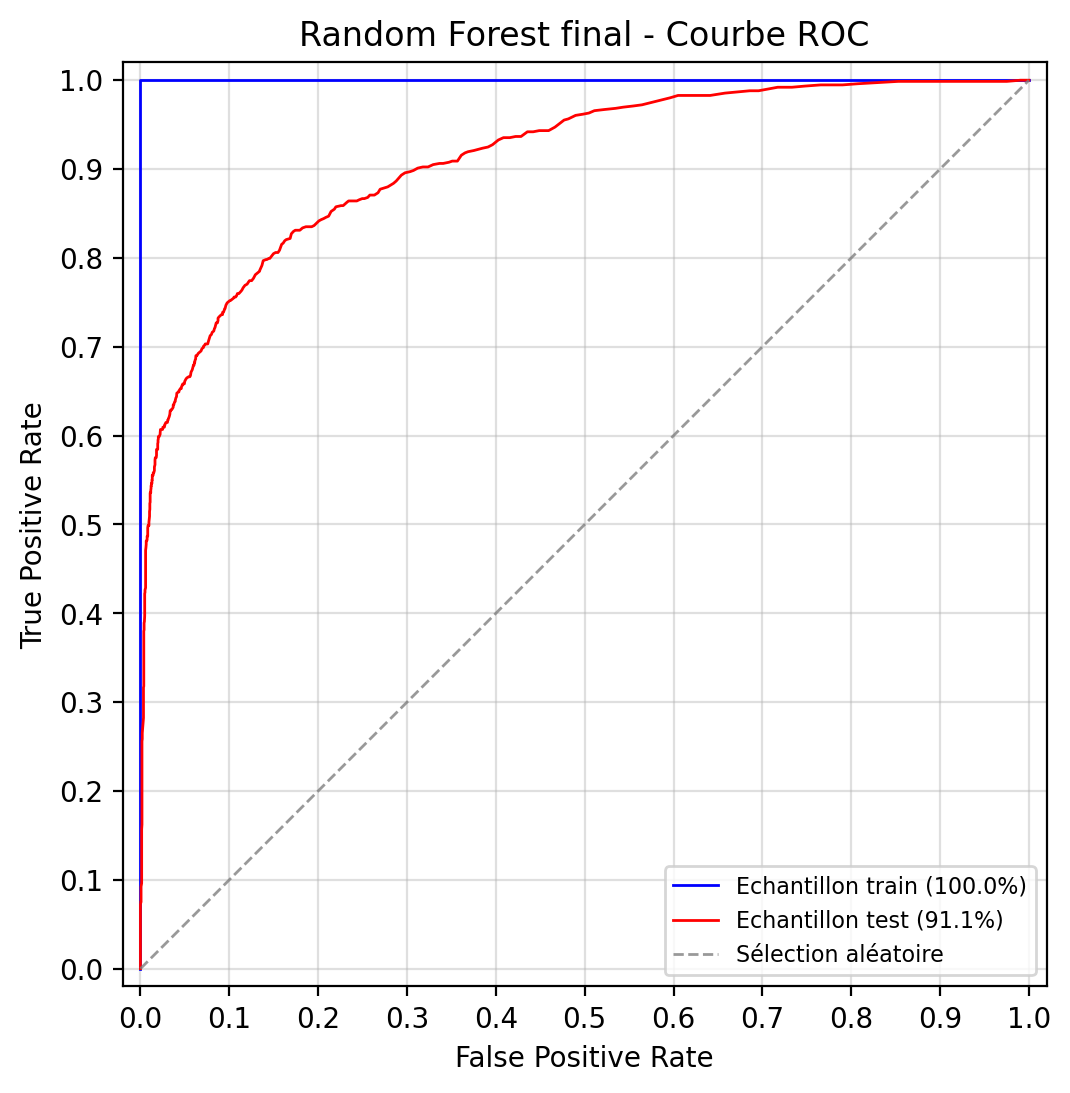

[0, 0.0, 0.002, 0.006, 0.008, 0.012, 0.016, 0.02, 0.026, 0.032, 0.04, 0.05, 0.062, 0.078, 0.102, 0.138, 0.202, 0.35840000000000144, 0.688, 0.806, 0.906, 0.994]
    score_bin  target_rate_train  target_rate_test bin_label
0           1               1.00              1.00         1
1           2               1.00              0.95         2
2           3               1.00              0.94         3
3           4               1.00              0.57         4
4           5               0.00              0.25         5
5           6               0.00              0.11         6
6           7               0.00              0.09         7
7           8               0.00              0.06         8
8           9               0.00              0.09         9
9          10               0.00              0.04        10
10         11               0.00              0.02        11
11         12               0.00              0.02        12
12         13               0.00              0

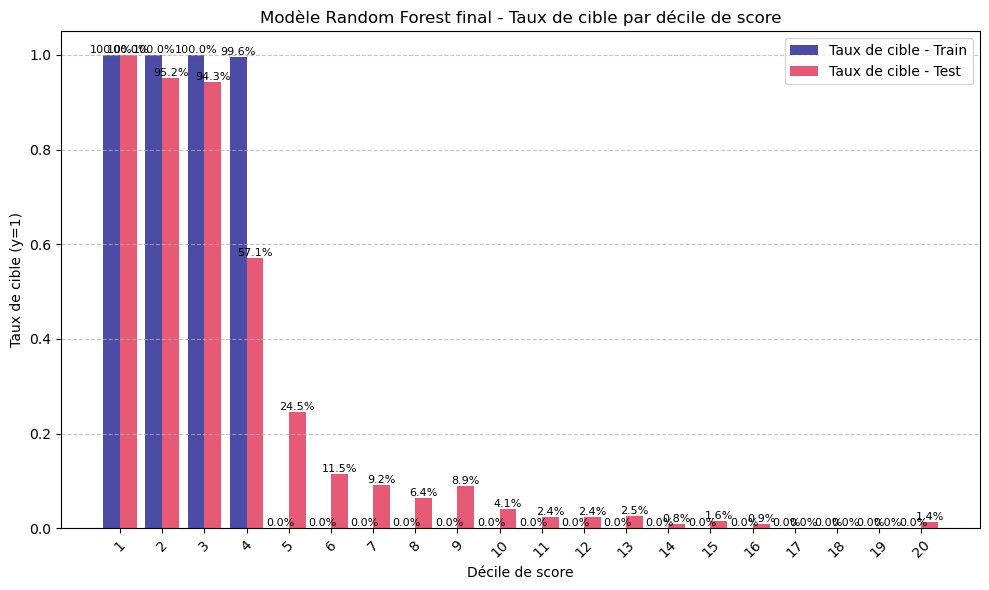

In [53]:
# ================================
# Modèle final Random Forest – configuration retenue
# ================================

 

# Définition du modèle final avec les hyperparamètres optimaux
rf_final = RandomForestClassifier(
    n_estimators=500,          # nombre d’arbres assurant stabilité et robustesse
    max_features="sqrt",       # limite la corrélation entre arbres
    min_samples_leaf=1,        # permet une discrimination fine
    max_depth=None,            # pas de contrainte artificielle sur la profondeur
    class_weight="balanced",   # priorité à la détection des churners
    random_state=42,
    n_jobs=-1                  # parallélisation du calcul
)

 

# Entraînement du modèle sur l’échantillon d’apprentissage
rf_final.fit(tree_X_train, y_train)
 

# ================================
# Évaluation des performances globales
# ================================

proba_train = rf_final.predict_proba(tree_X_train)[:, 1]
proba_test  = rf_final.predict_proba(tree_X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, proba_test)

dic_roc["Random Forest"] = {
    "fpr": fpr,
    "tpr": tpr,
    "roc_auc": roc_auc_score(y_test, proba_test)
}

cut_off = y_train.mean()


y_pred_train = (proba_train > cut_off).astype("int8")
y_pred_test  = (proba_test  > cut_off).astype("int8")


rf_final = "Random Forest final"


mat_conf_roc_curve(dic_roc_rf, rf_final, y_train, y_test, y_pred_train, y_pred_test, proba_train, proba_test)
analyze_target_rate_by_decile(rf_final, 20, y_train, y_test, proba_train, proba_test)

#### Évaluation globale du modèle Random Forest final

Le modèle de Random Forest optimisé présente d’excellentes performances de discrimination, confirmées par une AUC de 100 % sur l’échantillon d’apprentissage et de 91,1 % sur l’échantillon de test. Cet écart, maîtrisé et attendu, indique une très bonne capacité de généralisation, sans signe de sur-apprentissage excessif. La courbe ROC sur le jeu de test reste nettement au-dessus de la diagonale aléatoire, traduisant un pouvoir prédictif élevé sur l’ensemble des seuils.

**Analyse des performances de classification**

Sur l’échantillon d’apprentissage, le modèle atteint une précision, un rappel et un F1-score très élevés pour les deux classes, confirmant sa capacité à apprendre efficacement la structure des données. Sur l’échantillon de test, la performance reste solide : la classe non-churn est bien identifiée (rappel ≈ 0,82), tandis que la classe churn atteint un rappel de 0,83, ce qui est particulièrement pertinent dans un contexte métier où la détection des churners est prioritaire. La baisse de précision sur la classe churn reflète un compromis assumé en faveur de la réduction des faux négatifs.

**Qualité du ranking et exploitabilité métier**

L’analyse par déciles de score met en évidence une excellente séparation des individus. Les premiers déciles concentrent une très forte proportion de churners (jusqu’à 95–100 % dans les premiers groupes), tandis que les déciles inférieurs présentent des taux proches de zéro. Cette décroissance monotone du taux de cible confirme la qualité du score produit par le modèle et sa pertinence pour un usage opérationnel (ciblage marketing, actions de rétention priorisées).

**Robustesse et cohérence des résultats**

La cohérence entre les métriques globales (AUC), les indicateurs de classification (rappel, précision) et l’analyse par déciles démontre que le modèle n’est pas uniquement performant sur un seuil donné, mais qu’il fournit un score fiable et stable sur l’ensemble de la distribution. L’utilisation de class_weight="balanced" renforce cette cohérence en alignant les performances statistiques avec les objectifs métier.

**Conclusion**

En résumé, le modèle Random Forest final présente une excellente capacité de discrimination, une bonne généralisation et une forte valeur opérationnelle pour la détection du churn bancaire. Les résultats obtenus valident les choix méthodologiques effectués lors de l’optimisation des hyperparamètres et confirment que le modèle est robuste, interprétable dans son usage métier et directement exploitable en production.

L’enjeu se situe désormais dans le choix du ou des seuils de décision, qui doit être aligné avec les objectifs stratégiques de l’entreprise. Selon que l’on souhaite détecter un maximum de churners, au risque d’augmenter le nombre de faux positifs, ou au contraire cibler plus finement afin de limiter les coûts opérationnels et la saturation des équipes marketing, des seuils différents pourront être retenus. Cette étape constitue un levier essentiel pour adapter le modèle aux contraintes économiques et organisationnelles de la banque, et maximiser l’impact des actions de rétention mises en œuvre.

#### Choix du seuil pour le meilleur modèle

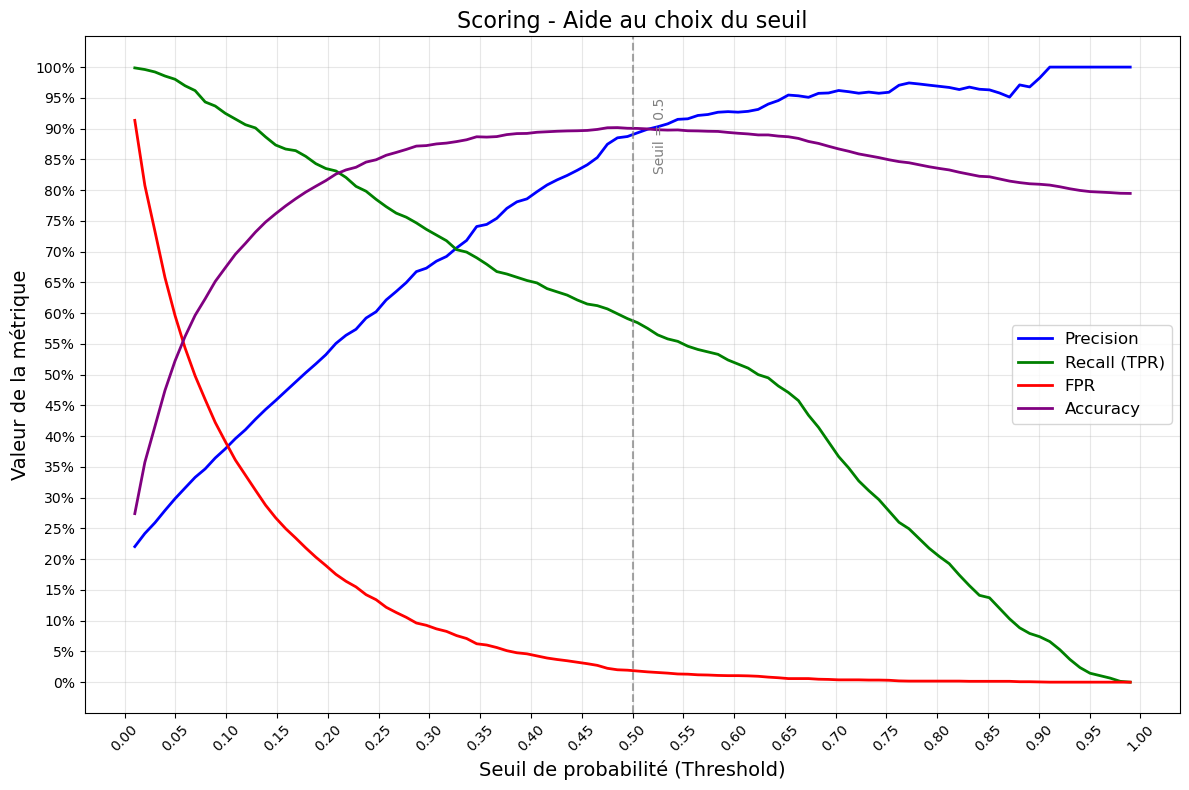

In [54]:
plot_metrics_vs_threshold(y_test, proba_test, n_thresholds=100, return_data=False)

- Le seuil correspondant à 50 % de rappel (0,17) permet de garantir la détection d’au moins la moitié des churners.
- Le seuil associé à 50 % de précision (0,63) assure que la moitié des clients ciblés sont réellement des churners.
- Le point de croisement entre les courbes de précision et de rappel (0,33) représente un compromis naturel entre détection et fiabilité.

Ces trois seuils constituent ainsi des points d’intérêt stratégiques pour adapter la décision aux objectifs métier.

In [55]:
print('\n'+'='*50)
mod = 'Forêt aléatoire - Seuil 0.23'
print(mod)
print('='*50)

# Spécification du seuil à utiliser pour la matrice de confusion 
cut_offs = [0.17, 0.63, 0.33]

for cut_off in cut_offs:
    mod = f"Forêt aléatoire - Seuil {cut_off:.2f}"

# Récupérer les prédictions binaires selon le cut_off
y_pred_train = (proba_train > cut_off).astype('int8')
y_pred_test = (proba_test > cut_off).astype('int8')
    
# Editer les matrices de confusion des échantillons d’apprentissage et de test ainsi que les courbes ROC associées
mat_conf(mod, y_train, y_test, y_pred_train, y_pred_test, proba_train, proba_test)


Forêt aléatoire - Seuil 0.23
Echantillon train
[[6836    5]
 [   0 1769]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6841
           1       1.00      1.00      1.00      1769

    accuracy                           1.00      8610
   macro avg       1.00      1.00      1.00      8610
weighted avg       1.00      1.00      1.00      8610

Echantillon test
[[2718  214]
 [ 225  533]]
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      2932
           1       0.71      0.70      0.71       758

    accuracy                           0.88      3690
   macro avg       0.82      0.82      0.82      3690
weighted avg       0.88      0.88      0.88      3690



### Comparaison des différents modèles

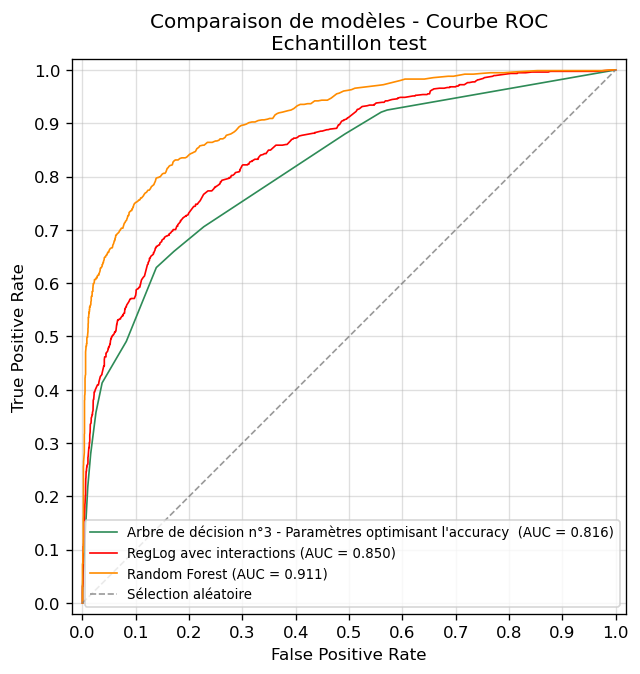

In [56]:
print('\n'+'='*50)
# Graphique de comparaison des modèles - Courbes ROC - Echantillon test
roc_curve_compare(dic_roc, 'Comparaison de modèles - Courbe ROC\nEchantillon test')